<a href="https://colab.research.google.com/github/rgrandym/data_science_cambridge/blob/main/CAM_DS_C301_9_1_Topic_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**First things first** - please go to 'File' and select 'Save a copy in Drive' so that you have your own version of this activity set up and ready to use.
Remember to update the portfolio index link to your own work once completed!

# Topic project 9.1 Using time series analysis for sales and demand forecasting

**Welcome to your topic project: Using time series analysis for sales and demand forecasting**

In this project, you will bridge the gap between theory and practical application by utilising time series analysis techniques to forecast sales and demand. Forecasting involves analysing historical sales data to accurately predict future sales trends and demand patterns.


Using time series analysis for sales and demand forecasting is crucial for data analysis in business because it can enhance decision-making by providing reliable sales and demand forecasts. This helps organisations reduce costs, maximise profits, and optimise resource allocation.


During this project, you will analyse the business scenario and explore the data set. You will then clean historical sales data, perform time series analysis using ARIMA, deep learning, or hybrid methods, and validate the models to ensure their accuracy in predicting future sales and demand patterns.


# Continuation of the Analysis from notebook1

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import statsmodels.graphics.api as smgraphics
from statsmodels.tsa.stattools import adfuller as adf
from statsmodels.tsa.stattools import kpss, acf, pacf
from pmdarima.arima import auto_arima
from statsmodels.tsa.seasonal import seasonal_decompose 
from statsmodels.tsa.seasonal import STL
from matplotlib.lines import Line2D
import statsmodels.api as sm
from pandas.tseries.holiday import USFederalHolidayCalendar
from statsmodels.graphics.tsaplots import plot_pacf 
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.stats.diagnostic import acorr_ljungbox

import lightgbm as lgb
from sktime.forecasting.compose import (TransformedTargetForecaster, make_reduction)
from sktime.forecasting.model_selection import (ExpandingWindowSplitter, ForecastingGridSearchCV)
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sktime.forecasting.trend import PolynomialTrendForecaster
from sktime.transformations.series.detrend import Deseasonalizer, Detrender
import calendar
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import het_arch
import warnings
# Suppress specific warnings.
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# Load parquet format. This is better than csv format, because it conserves all the original metadata, including frequency, contained in the original dataframe saved from notebook1 (everything comes back exactly as saved)
df_uk_weekly_post2012 = pd.read_parquet('df_uk_weekly_post2012.parquet')

# Display the first few rows of the dataset
display(df_uk_weekly_post2012.head())

,ISBN,Title,Author,Interval,Volume,Value,ASP,RRP,Binding,Imprint,Publisher_Group,Product_Class,Category
End_Date,,,,,,,,,,,,,
2012-01-07,9780241003008,The Very Hungry Caterpillar,"Carle, Eric",201201,512,2522.13,4.9260,7.99,Hardback,Puffin Books,Penguin Grp,Y1.3 Picture Books,"Y Children's, YA & Educational"
2012-01-07,9780722532935,The Alchemist,"Coelho, Paulo",201201,518,3601.76,6.9532,9.99,Paperback,Thorsons,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction
2012-01-14,9780722532935,The Alchemist,"Coelho, Paulo",201202,533,3610.12,6.7732,9.99,Paperback,Thorsons,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction
2012-01-14,9780241003008,The Very Hungry Caterpillar,"Carle, Eric",201202,519,2473.31,4.7655,7.99,Hardback,Puffin Books,Penguin Grp,Y1.3 Picture Books,"Y Children's, YA & Educational"
2012-01-21,9780241003008,The Very Hungry Caterpillar,"Carle, Eric",201203,574,2757.83,4.8046,7.99,Hardback,Puffin Books,Penguin Grp,Y1.3 Picture Books,"Y Children's, YA & Educational"


The Very Hungry Caterpillar


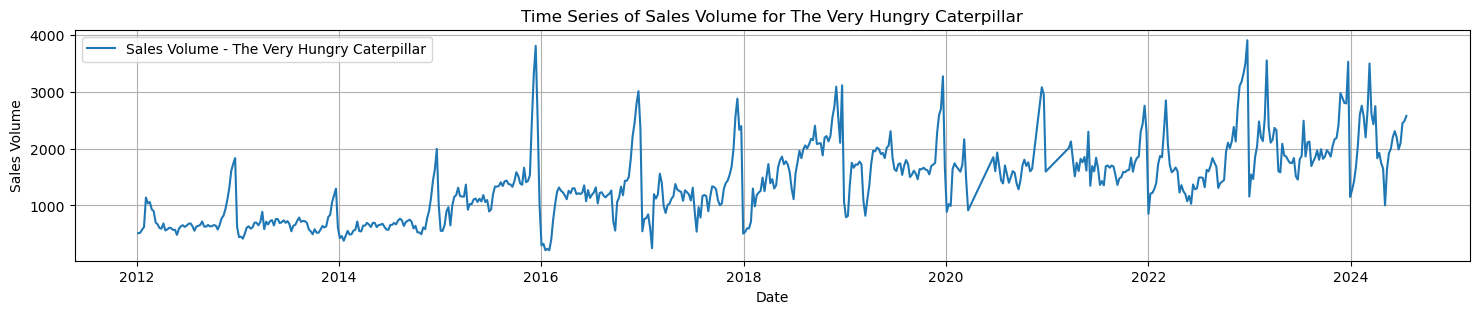

The Alchemist


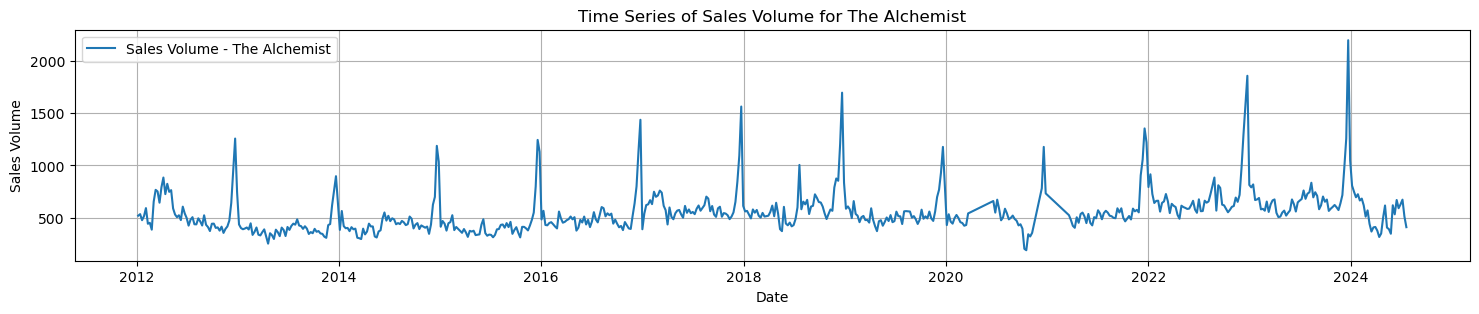

In [3]:
# List of ISBNs to plot
isbns_to_plot = ['9780241003008', '9780722532935']

# Loop through the ISBNs and plot
for isbn in isbns_to_plot:
    # Filter the df_uk_weekly_post2012 by the ISBN
    book_data = df_uk_weekly_post2012[df_uk_weekly_post2012['ISBN'] == isbn]

    # Get the unique title(s) for the ISBN
    title = book_data['Title'].unique()[0]
    print(title)

    # Plot the Volume over Time
    plt.figure(figsize=(18, 3))
    plt.plot(book_data.index, book_data['Volume'], label=f'Sales Volume - {title}')
    plt.title(f'Time Series of Sales Volume for {title}')
    plt.xlabel('Date')
    plt.ylabel('Sales Volume')
    plt.grid(True)
    plt.legend()
    plt.show()


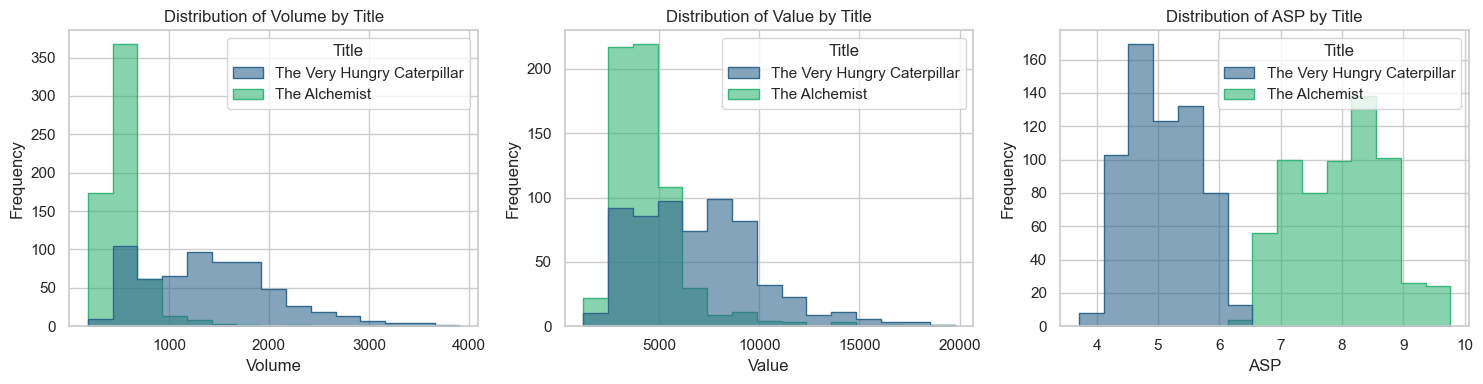

In [4]:
# @title: "Plotting Sales Volume Over Time for Two Books"
# Function to plot the distribution of metrics for two books
def plot_metrics_comparison(data, metrics=['Volume', 'Value', 'ASP']):
    sns.set_theme(style="whitegrid", palette="viridis")
    
    plt.figure(figsize=(15, 4))
    
    # Plot each metric with both books' distributions
    for i, metric in enumerate(metrics, 1):
        plt.subplot(1, 3, i)
        sns.histplot(data=data, x=metric, hue='Title', 
                    kde=False, bins=15, element='step', 
                    palette='viridis', alpha=0.6)
        plt.title(f'Distribution of {metric} by Title')
        plt.xlabel(metric)
        plt.ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

# Usage
plot_metrics_comparison(df_uk_weekly_post2012)

The ADF test can sometimes be less reliable when a series has a strong deterministic trend. While the series may be "trend-stationary" (stationary around a trend), the visual ACF plot correctly identified that this trend needs to be addressed for modeling. For practical purposes, given the very clear trend in the data and the slow ACF decay, it is often better to trust the visual evidence and proceed with differencing.

# Decomposition of the Data

In [5]:
# Decompose the data and determine the STL residuals. Store the residuals as `stl_object.resid`.
# Check for leap years
# --- Check for leap years (irrelevant for weekly data, but kept for reference) ---
has_leap_years = any((df_uk_weekly_post2012.index.year % 4 == 0) & 
                    ((df_uk_weekly_post2012.index.year % 100 != 0) | 
                     (df_uk_weekly_post2012.index.year % 400 == 0)))

# --- STL Parameters for Weekly Data ---
# STL Parameters for Weekly Data
period = 52       # Yearly seasonality (52 weeks)
seasonal = 7      # Short-term seasonality (weekly patterns)
trend = 53        # Long-term trend (must be > period and odd)

# List of ISBNs to analyze
# Dictionary to store results (ISBN -> decomposition components)
stl_results = {}

# List of ISBNs to analyze
isbns_to_plot = ['9780241003008', '9780722532935']

for isbn in isbns_to_plot:
    # Filter data for the current book
    book_data = df_uk_weekly_post2012[df_uk_weekly_post2012['ISBN'] == isbn]
    title = book_data['Title'].unique()[0]
    
    print(f"\nAnalyzing: {title} (ISBN: {isbn})")
    
    # --- STL Decomposition ---
    stl = STL(
        book_data['Volume'].dropna(),  # Ensure no NaNs
        period=52,       # Weekly seasonality (52 weeks/year)
        seasonal=7,      # Short-term patterns (odd number < period)
        trend=53,        # Long-term trend (odd number > period)
        robust=True      # Robust to outliers
    ).fit()
    
    # --- Store ALL components in the dictionary ---
    stl_results[isbn] = {
        'title': title,
        'observed': stl.observed,     # Original data
        'trend': stl.trend,           # Trend component
        'seasonal': stl.seasonal,     # Seasonal component
        'resid': stl.resid,           # Residuals
        'model': stl                  # Entire STL object (optional)
    }


Analyzing: The Very Hungry Caterpillar (ISBN: 9780241003008)

Analyzing: The Alchemist (ISBN: 9780722532935)


In [6]:
# Extract components for each book
# Extract components for "The Very Hungry Caterpillar" (ISBN: 9780241003008)
stl_residuals_hungry_cater = stl_results['9780241003008']['resid']
stl_trend_hungry_cater = stl_results['9780241003008']['trend']
stl_seasonal_hungry_cater = stl_results['9780241003008']['seasonal']
stl_observed_hungry_cater = stl_results['9780241003008']['observed']

# Extract components for "The Alchemist" (ISBN: 9780722532935)
stl_residuals_alchemist = stl_results['9780722532935']['resid']
stl_trend_alchemist = stl_results['9780722532935']['trend']
stl_seasonal_alchemist = stl_results['9780722532935']['seasonal']
stl_observed_alchemist = stl_results['9780722532935']['observed']

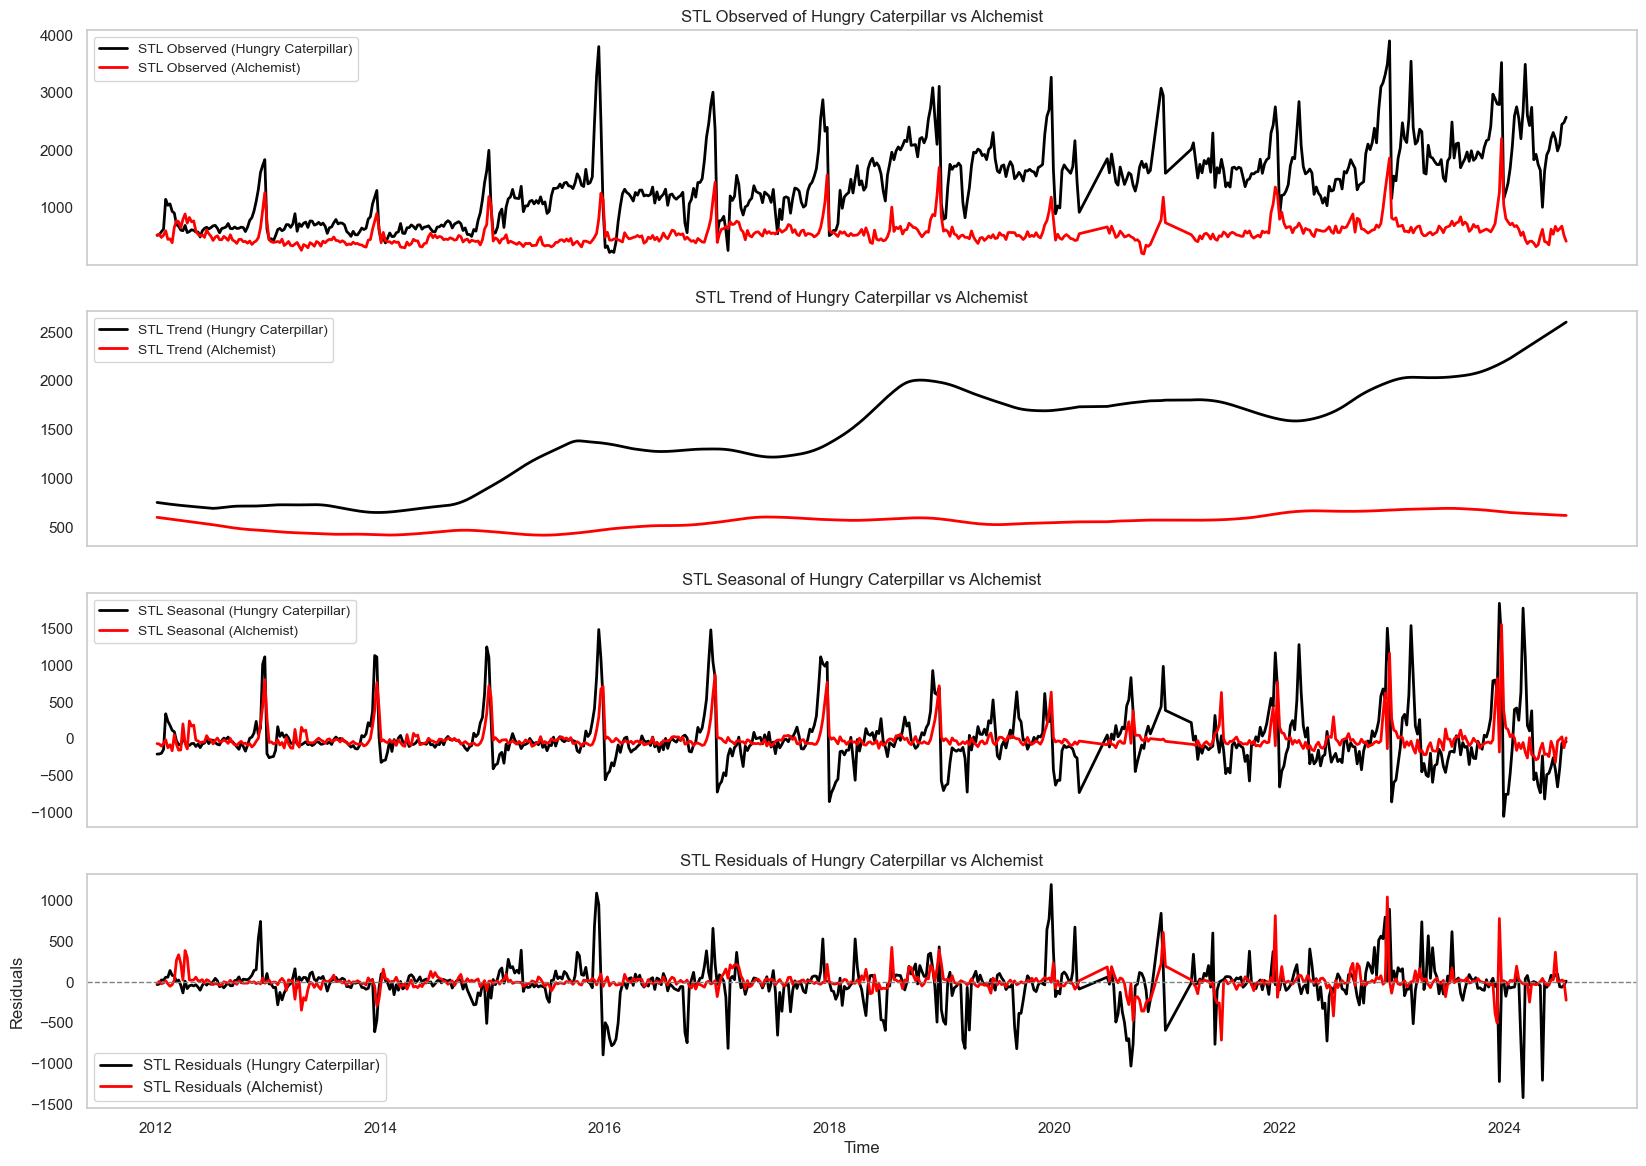

In [7]:
# Plot the results of the STL decomposition
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(20, 14), sharex=True) 
# Plot the STL observed data
ax1.plot(stl_observed_hungry_cater, color='black', label='STL Observed (Hungry Caterpillar)', linewidth=2, linestyle='-')
ax1.plot(stl_observed_alchemist, color='red', label='STL Observed (Alchemist)', linewidth=2, linestyle='-')
ax1.set_title('STL Observed of Hungry Caterpillar vs Alchemist')
ax1.grid(False)
ax1.legend(loc='upper left', fontsize=10)

# Plot the STL trend
ax2.plot(stl_trend_hungry_cater, color='black', label='STL Trend (Hungry Caterpillar)', linewidth=2, linestyle='-')
ax2.plot(stl_trend_alchemist, color='red', label='STL Trend (Alchemist)', linewidth=2, linestyle='-')
ax2.set_title('STL Trend of Hungry Caterpillar vs Alchemist')
ax2.grid(False)
ax2.legend(loc='upper left', fontsize=10)

# Plot the STL seasonal component
ax3.plot(stl_seasonal_hungry_cater, color='black', label='STL Seasonal (Hungry Caterpillar)', linewidth=2, linestyle='-')
ax3.plot(stl_seasonal_alchemist, color='red', label='STL Seasonal (Alchemist)', linewidth=2, linestyle='-')
ax3.set_title('STL Seasonal of Hungry Caterpillar vs Alchemist')
ax3.legend(loc='upper left', fontsize=10)
ax3.grid(False)

# Plot the STL residuals
ax4.plot(stl_residuals_hungry_cater, color='black', label='STL Residuals (Hungry Caterpillar)', linewidth=2, linestyle='-')
ax4.plot(stl_residuals_alchemist, color='red', label='STL Residuals (Alchemist)', linewidth=2, linestyle='-')
ax4.axhline(0, color='gray', linestyle='--', linewidth=1)
ax4.set_title('STL Residuals of Hungry Caterpillar vs Alchemist')
ax4.set_xlabel('Time')
ax4.set_ylabel('Residuals')
ax4.grid(False)
ax4.legend(loc='lower left')


plt.show()

In [8]:
# Display the STL decomposition results
# Residual Analysis
print(f"\nSTL Parameters:")
print(f"Period: {period} (seasonality length)")
print(f"Seasonal: {seasonal} (smoothing window)")
print(f"Trend: {trend} (smoothing window)\n")

print("Residual Statistics:")
print("Hungry Caterpillar:")
print(stl_residuals_hungry_cater.describe())

print("\nComponent Strengths:")
print(f"Seasonal: {1 - (stl_residuals_hungry_cater.var()/(stl_seasonal_hungry_cater + stl_residuals_hungry_cater).var()):.2f}")
print(f"Trend: {1 - (stl_trend_hungry_cater.var()/(stl_trend_hungry_cater + stl_residuals_hungry_cater).var()):.2f}")

print("\nResidual Statistics:")
print("Alchemist:")
print(stl_residuals_alchemist.describe())

print("\nComponent Strengths:")
print(f"Seasonal: {1 - (stl_residuals_alchemist.var()/(stl_seasonal_alchemist + stl_residuals_alchemist).var()):.2f}")
print(f"Trend: {1 - (stl_trend_alchemist.var()/(stl_trend_alchemist + stl_residuals_alchemist).var()):.2f}")


STL Parameters:
Period: 52 (seasonality length)
Seasonal: 7 (smoothing window)
Trend: 53 (smoothing window)

Residual Statistics:
Hungry Caterpillar:
count     628.000000
mean      -20.252522
std       254.883733
min     -1419.269632
25%       -70.356771
50%        -6.659359
75%        59.311952
max      1198.163869
Name: resid, dtype: float64

Component Strengths:
Seasonal: 0.67
Trend: 0.18

Residual Statistics:
Alchemist:
count     628.000000
mean        3.989242
std       114.949329
min      -713.159573
25%       -23.662164
50%        -0.018998
75%        24.815862
max      1045.833529
Name: resid, dtype: float64

Component Strengths:
Seasonal: 0.61
Trend: 0.69


Notes:

- The hungry caterpillar: Strong seasonal component (0.67) with weak long-term trend component (0.18). This means that sales are highly predictable with clear seasonal patterns.
- The alchemist: Strong seasonal component (0.61), the trend component (0.69) is even stronger. This indicates a more stable sales pattern over time, most likely influenced by long-term factors such as cultural relevance and consistent readership.

### Check for Stationarity (ADF & KPSS)

In [9]:
# Perform ADF and KPSS tests on the residuals
# Prepare data
book1 = df_uk_weekly_post2012[df_uk_weekly_post2012['ISBN'] == '9780241003008']['Volume']
book2 = df_uk_weekly_post2012[df_uk_weekly_post2012['ISBN'] == '9780722532935']['Volume']

def print_adf_results(series, name):
    print(f"\nADF Test for {name}:")
    result = adf(series)
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")
    print("Conclusion:", "Stationary" if result[1] < 0.05 else "Non-stationary")

def print_kpss_results(series, name):
    print(f"\nKPSS Test for {name}:")
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")  # Suppress interpolation warnings
            result = kpss(series, regression='ct')
            print(f"KPSS Statistic: {result[0]:.4f}")
            
            # Handle p-value reporting for extreme cases
            if result[1] > 0.1:
                p_msg = "> 0.10"
            elif result[1] < 0.01:
                p_msg = "< 0.01"
            else:
                p_msg = f"{result[1]:.4f}"
            print(f"p-value: {p_msg}")
            
            print("Critical Values:")
            for key, value in result[3].items():
                print(f"   {key}: {value:.4f}")
            
            # Improved conclusion logic
            if result[0] > result[3]['5%']:
                print("Conclusion: Non-stationary (reject null at 5% level)")
            else:
                print("Conclusion: Stationary (fail to reject null)")
                
    except Exception as e:
        print(f"Error in KPSS test: {str(e)}")

# Run tests
import warnings
print_adf_results(book1, "The Very Hungry Caterpillar")
print_adf_results(book2, "The Alchemist")

print_kpss_results(book1, "The Very Hungry Caterpillar")
print_kpss_results(book2, "The Alchemist")


ADF Test for The Very Hungry Caterpillar:
ADF Statistic: -2.2003
p-value: 0.2061
Critical Values:
   1%: -3.4410
   5%: -2.8663
   10%: -2.5693
Conclusion: Non-stationary

ADF Test for The Alchemist:
ADF Statistic: -9.7927
p-value: 0.0000
Critical Values:
   1%: -3.4408
   5%: -2.8662
   10%: -2.5692
Conclusion: Stationary

KPSS Test for The Very Hungry Caterpillar:
KPSS Statistic: 0.1065
p-value: 0.1000
Critical Values:
   10%: 0.1190
   5%: 0.1460
   2.5%: 0.1760
   1%: 0.2160
Conclusion: Stationary (fail to reject null)

KPSS Test for The Alchemist:
KPSS Statistic: 0.0744
p-value: 0.1000
Critical Values:
   10%: 0.1190
   5%: 0.1460
   2.5%: 0.1760
   1%: 0.2160
Conclusion: Stationary (fail to reject null)


KPSS Analysis:
- The Very Hungry Caterpillar:
  - Trend-stationary (no unit root but has deterministic trend). 
- The Alchemist:
  - Confirmed stationary. Safe to model as is.

ADF Analysis:
- The Very Hungry Caterpillar:
  - Non-stationary (fail to reject null hypothesis)
  - The conflicting ADF/KPSS for Hungry Caterpillar suggests trend-stationarity. Detrend instead of differencing would be more appropriate.

- The Alchemist:
  - Stationary (reject null hypothesis)
  - Can model directly. Differencing not needed. Proceed directly with analysis

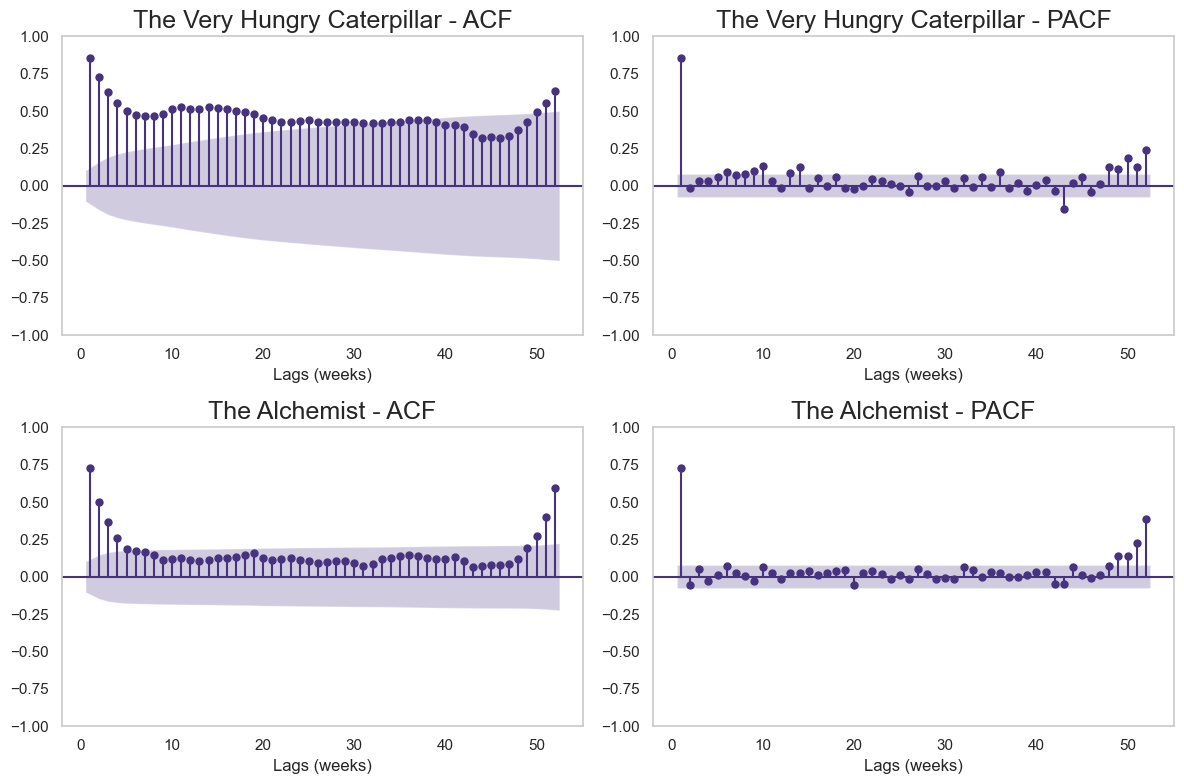

In [47]:
# Plot ACF and PACF for the two books

# Prepare data
book1 = df_uk_weekly_post2012[df_uk_weekly_post2012['ISBN'] == '9780241003008']
book2 = df_uk_weekly_post2012[df_uk_weekly_post2012['ISBN'] == '9780722532935']

# Create figure
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))

# Common settings
acf_kwargs = {
    'lags': 52,  # Weekly data - show 1 year
    'alpha': 0.01,
    'zero': False,
    'title': None
}

pacf_kwargs = {
    'lags': 52,
    'alpha': 0.05,
    'zero': False,
    'method': 'ywm',
    'title': None
}

# Plot ACF/PACF for Book 1
plot_acf(book1['Volume'], ax=ax1, **acf_kwargs)
plot_pacf(book1['Volume'], ax=ax2, **pacf_kwargs)
ax1.set_title('The Very Hungry Caterpillar - ACF', fontsize=18)
ax2.set_title('The Very Hungry Caterpillar - PACF', fontsize=18)

# Plot ACF/PACF for Book 2
plot_acf(book2['Volume'], ax=ax3, **acf_kwargs)
plot_pacf(book2['Volume'], ax=ax4, **pacf_kwargs)
ax3.set_title('The Alchemist - ACF', fontsize=18)
ax4.set_title('The Alchemist - PACF', fontsize=18)

# Formatting
for ax in (ax1, ax2, ax3, ax4):
    ax.set_xlabel('Lags (weeks)')
    ax.grid(False)

plt.tight_layout()
plt.show()

### Perform Differencing (If Needed):

There no need for differencing this data prior to modeling. However, the The Hungry Caterpillar shows a trend-stationary pattern, so detrending is recommended.

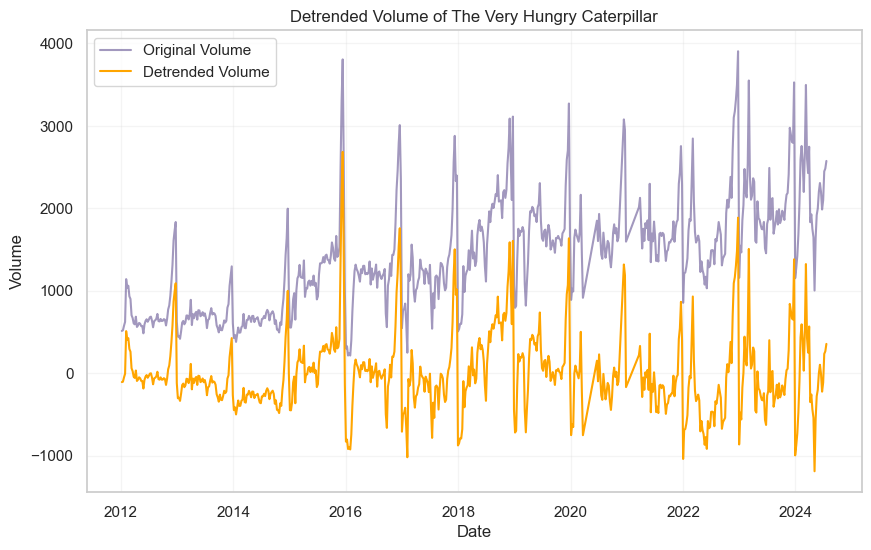

In [11]:
# Detrending the "The Hungry Caterpillar" data

hung_caterp = df_uk_weekly_post2012[df_uk_weekly_post2012['ISBN'] == '9780241003008']
detrender = Detrender()
hung_caterp_detrended = detrender.fit_transform(hung_caterp['Volume'])  
# Plot the detrended data
plt.figure(figsize=(10, 6))
plt.plot(hung_caterp.index, hung_caterp['Volume'], label='Original Volume', alpha=0.5)
plt.plot(hung_caterp.index, hung_caterp_detrended, label='Detrended Volume', color='orange')
plt.title('Detrended Volume of The Very Hungry Caterpillar')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [12]:
# We need to applied the same frequency to the detrended series as the original series. The original dataset starts on SAT and I did not change that, so we need to use the same here.
hung_caterp_detrended = hung_caterp_detrended.asfreq('W-SAT')
# Fill NAs with 0
hung_caterp_detrended = hung_caterp_detrended.fillna(0)

In [13]:
print(hung_caterp_detrended.index.inferred_freq)

W-SAT


In [14]:
print(hung_caterp_detrended.isna().sum())  # Check for NaNs in the detrended series

0


### Check Seasonality again

In [15]:
# STL Parameters for Weekly Data
period = 52  # Yearly seasonality (52 weeks)
seasonal = 7  # Short-term seasonality (weekly patterns)
trend = 53   # Long-term trend (must be > period and odd)

# Dictionary to store results
stl_results = {}


# Create book dictionary for STL analysis
books = {
    'hung_caterp_detrended': {
        'data': hung_caterp_detrended,
        'title': 'The Very Hungry Caterpillar (Detrended)'
    }
}

# Run STL decomposition
for book_id, book_info in books.items():
    book_data = book_info['data']
    title = book_info['title']
    
    print(f"\nAnalyzing: {title}")
    print(f"Data shape: {book_data.shape}")
    print(f"Data type: {type(book_data)}")
    
    # STL Decomposition
    stl = STL(
        book_data.dropna(),  # Remove any NaN values
        period=period,
        seasonal=seasonal,
        trend=trend,
        robust=True
    ).fit()
    
    # Store results
    stl_results[book_id] = {
        'title': title,
        'observed': stl.observed,
        'trend': stl.trend,
        'seasonal': stl.seasonal,
        'resid': stl.resid,
        'model': stl
    }
    
    print(f"STL decomposition completed for {title}")


Analyzing: The Very Hungry Caterpillar (Detrended)
Data shape: (655,)
Data type: <class 'pandas.core.series.Series'>
STL decomposition completed for The Very Hungry Caterpillar (Detrended)


In [16]:
# Extract components for "The Very Hungry Caterpillar" (ISBN: 9780241003008)
 # The Very Hungry Caterpillar (Detrended)
detrended_results = stl_results['hung_caterp_detrended']

# Extract individual components
observed_detrended = detrended_results['observed']  # The detrended input data
trend_detrended = detrended_results['trend']       # Trend component
seasonal_detrended = detrended_results['seasonal'] # Seasonal component
resid_detrended = detrended_results['resid']       # Residuals
model_detrended = detrended_results['model'] 


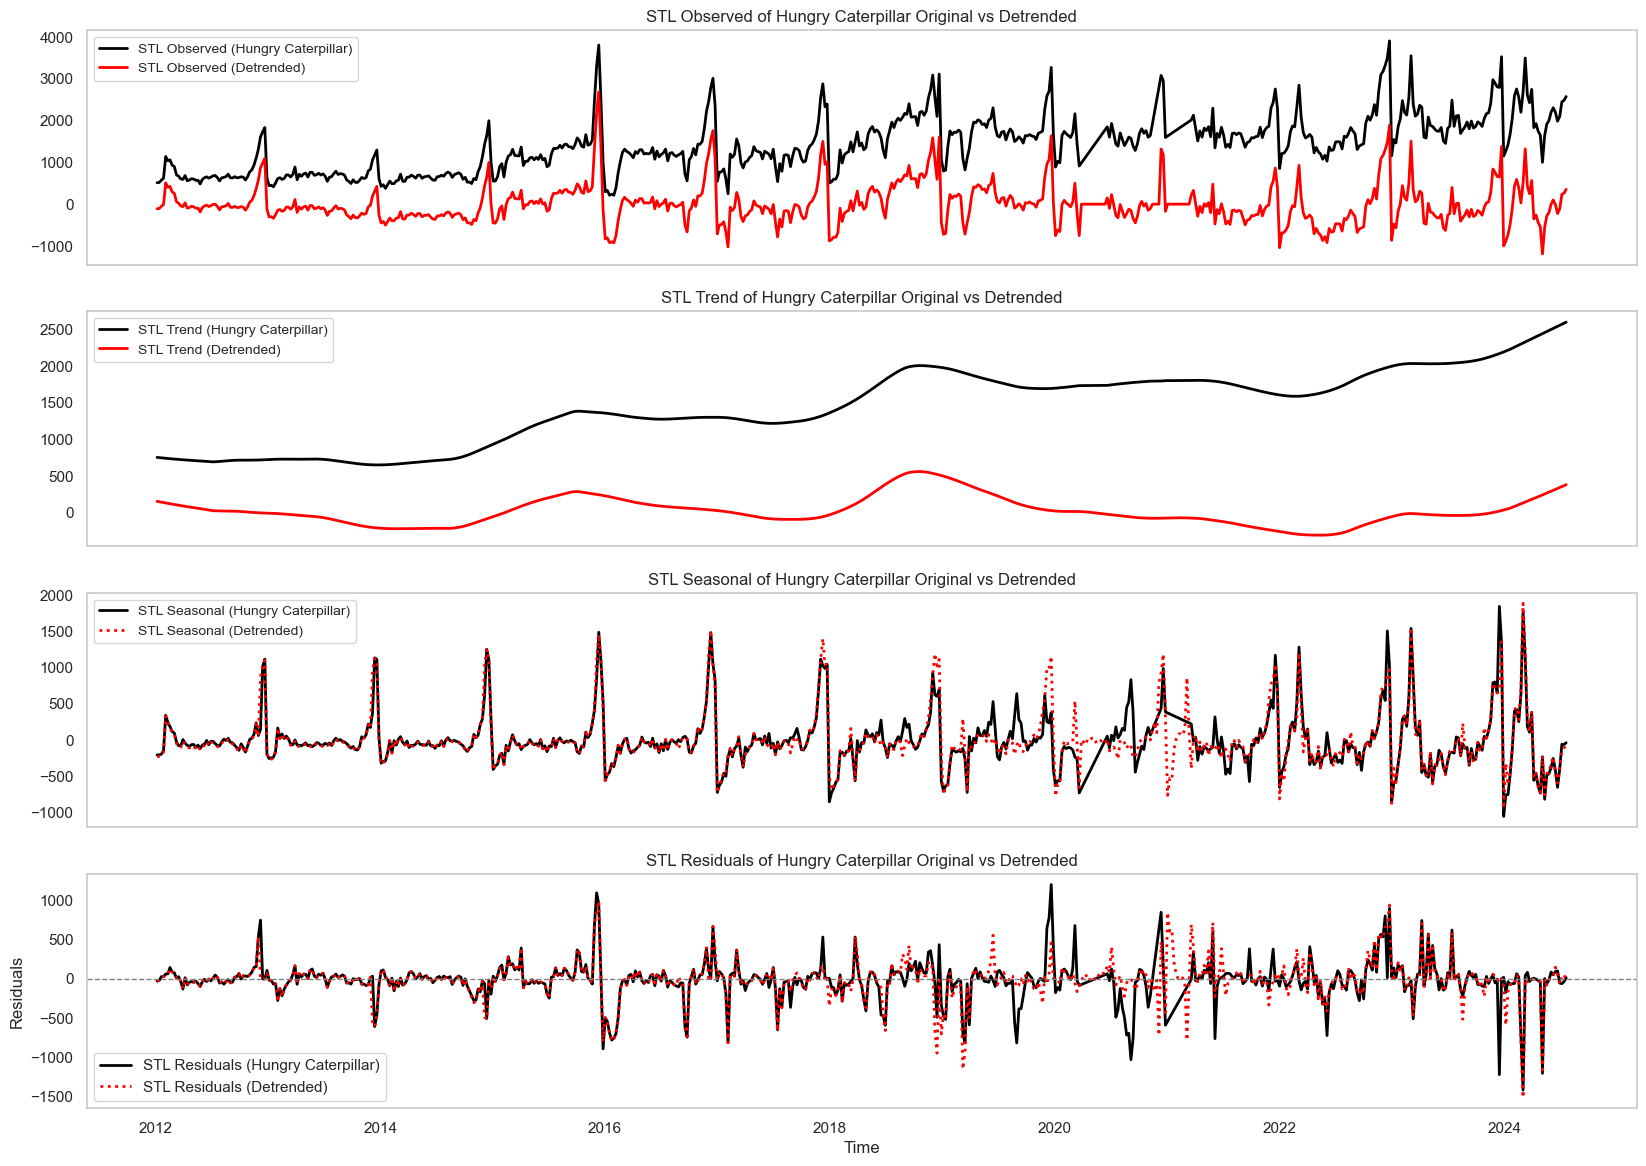

In [17]:
# Plot the results of the STL decomposition
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(20, 14), sharex=True) 
# Plot the STL observed data
ax1.plot(stl_observed_hungry_cater, color='black', label='STL Observed (Hungry Caterpillar)', linewidth=2, linestyle='-')
ax1.plot(observed_detrended, color='red', label='STL Observed (Detrended)', linewidth=2, linestyle='-')
ax1.set_title('STL Observed of Hungry Caterpillar Original vs Detrended')
ax1.grid(False)
ax1.legend(loc='upper left', fontsize=10)

# Plot the STL trend
ax2.plot(stl_trend_hungry_cater, color='black', label='STL Trend (Hungry Caterpillar)', linewidth=2, linestyle='-')
ax2.plot(trend_detrended, color='red', label='STL Trend (Detrended)', linewidth=2, linestyle='-')
ax2.set_title('STL Trend of Hungry Caterpillar Original vs Detrended')
ax2.grid(False)
ax2.legend(loc='upper left', fontsize=10)

# Plot the STL seasonal component
ax3.plot(stl_seasonal_hungry_cater, color='black', label='STL Seasonal (Hungry Caterpillar)', linewidth=2, linestyle='-')
ax3.plot(seasonal_detrended, color='red', label='STL Seasonal (Detrended)', linewidth=2, linestyle='dotted')
ax3.set_title('STL Seasonal of Hungry Caterpillar Original vs Detrended')
ax3.legend(loc='upper left', fontsize=10)
ax3.grid(False)

# Plot the STL residuals
ax4.plot(stl_residuals_hungry_cater, color='black', label='STL Residuals (Hungry Caterpillar)', linewidth=2, linestyle='-')
ax4.plot(resid_detrended, color='red', label='STL Residuals (Detrended)', linewidth=2, linestyle='dotted')
ax4.axhline(0, color='gray', linestyle='--', linewidth=1)
ax4.set_title('STL Residuals of Hungry Caterpillar Original vs Detrended')
ax4.set_xlabel('Time')
ax4.set_ylabel('Residuals')
ax4.grid(False)
ax4.legend(loc='lower left')


plt.show()

Notes: The detrending operation seemed to have worked well, as shown in the plot above, the trend component for the hungry caterpillar detrended dataset is now more stable and close to zero.

### ADF and KPSS Tests on Detrended Data

In [18]:
# Perform ADF and KPSS tests on the residuals

def print_adf_results(series, name):
    print(f"\nADF Test for {name}:")
    result = adf(series)
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")
    print("Conclusion:", "Stationary" if result[1] < 0.05 else "Non-stationary")

def print_kpss_results(series, name):
    print(f"\nKPSS Test for {name}:")
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")  # Suppress interpolation warnings
            result = kpss(series, regression='c') # 'c' for constant (level stationarity) since the detrended series should not have a trend
            print(f"KPSS Statistic: {result[0]:.4f}")
            
            # Handle p-value reporting for extreme cases
            if result[1] > 0.1:
                p_msg = "> 0.10"
            elif result[1] < 0.01:
                p_msg = "< 0.01"
            else:
                p_msg = f"{result[1]:.4f}"
            print(f"p-value: {p_msg}")
            
            print("Critical Values:")
            for key, value in result[3].items():
                print(f"   {key}: {value:.4f}")
            
            # Improved conclusion logic
            if result[0] > result[3]['5%']:
                print("Conclusion: Non-stationary (reject null at 5% level)")
            else:
                print("Conclusion: Stationary (fail to reject null)")
                
    except Exception as e:
        print(f"Error in KPSS test: {str(e)}")

# Run tests
import warnings
print_adf_results(hung_caterp_detrended, "The Very Hungry Caterpillar")
print_kpss_results(hung_caterp_detrended, "The Very Hungry Caterpillar")


ADF Test for The Very Hungry Caterpillar:
ADF Statistic: -5.1237
p-value: 0.0000
Critical Values:
   1%: -3.4406
   5%: -2.8661
   10%: -2.5692
Conclusion: Stationary

KPSS Test for The Very Hungry Caterpillar:
KPSS Statistic: 0.1484
p-value: 0.1000
Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390
Conclusion: Stationary (fail to reject null)


Note: After detrending the Hungry Caterpillar data is confirmed to be stationary by both the ADF and KPSS tests. This means that the data is now suitable for modeling without further differencing.

### Check for Autocorrelation Again

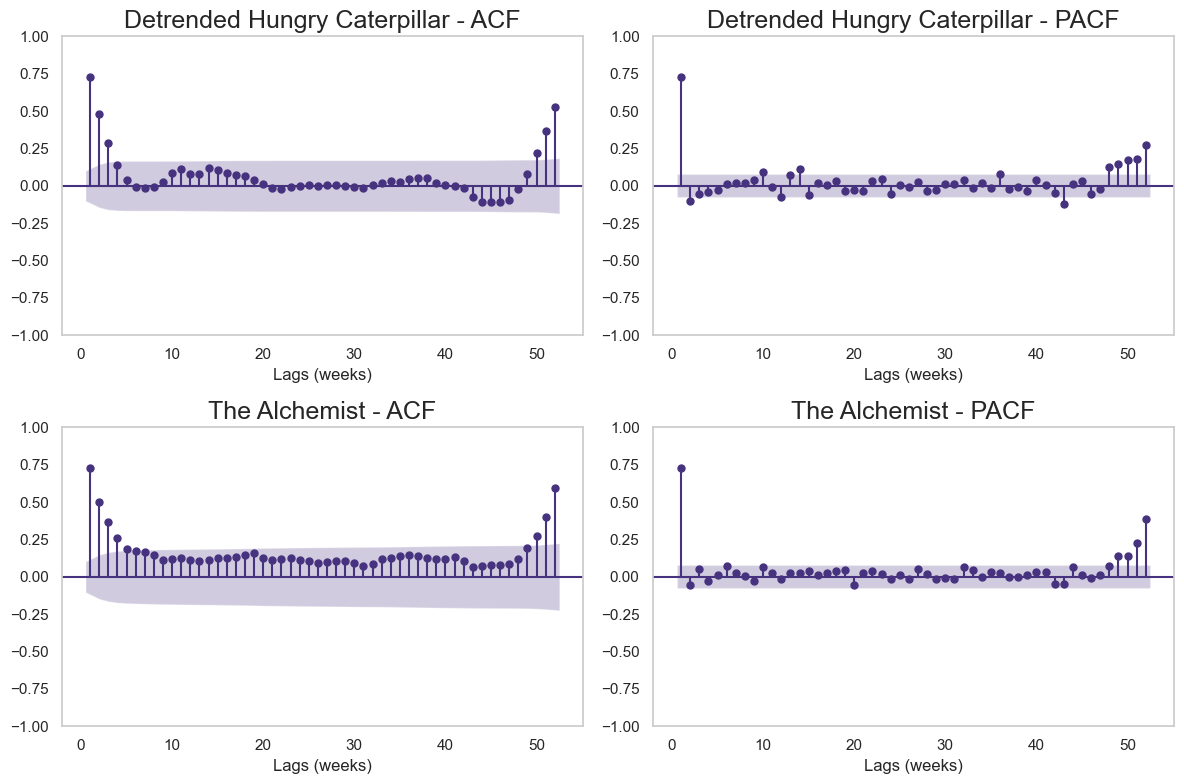

In [48]:
# Plot ACF and PACF for the two books

# Prepare data - assuming hung_caterp_detrended is already a Series
hung_caterp_detrended 
alchemist = df_uk_weekly_post2012[df_uk_weekly_post2012['ISBN'] == '9780722532935']['Volume']

# Create figure
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))

# Common settings
acf_kwargs = {
    'lags': 52,
    'alpha': 0.01,
    'zero': False,
    'title': None
}

pacf_kwargs = {
    'lags': 52,
    'alpha': 0.05,
    'zero': False,
    'method': 'ywm',
    'title': None
}

# Plot ACF/PACF for Detrended Hungry Caterpillar
plot_acf(hung_caterp_detrended, ax=ax1, **acf_kwargs)
plot_pacf(hung_caterp_detrended, ax=ax2, **pacf_kwargs)
ax1.set_title('Detrended Hungry Caterpillar - ACF', fontsize=18)
ax2.set_title('Detrended Hungry Caterpillar - PACF', fontsize=18)

# Plot ACF/PACF for The Alchemist (original)
plot_acf(alchemist, ax=ax3, **acf_kwargs)
plot_pacf(alchemist, ax=ax4, **pacf_kwargs)
ax3.set_title('The Alchemist - ACF', fontsize=18)
ax4.set_title('The Alchemist - PACF', fontsize=18)

# Formatting
for ax in (ax1, ax2, ax3, ax4):
    ax.set_xlabel('Lags (weeks)')
    ax.grid(False)

plt.tight_layout()
plt.show()

# Modeling the data with AutoArima

### The forecast horizon is the final 32 weeks of data. All prior data (from 2012-01-01 onwards) can be used as the training data.

In [20]:
# Split the data for both books into train and test sets.
# Split the data for the Hungry Caterpillar
ts_train_hung_caterp_detrended = hung_caterp_detrended[:-32]
ts_test_hung_caterp_detrended = hung_caterp_detrended[-32:]

# Split the data for the Alchemist
alchemist = df_uk_weekly_post2012[df_uk_weekly_post2012['ISBN'] == '9780722532935']['Volume']
# Ensure the Alchemist data has the same frequency as the original dataset
alchemist = alchemist.asfreq('W-SAT')
# Fill NAs with 0
alchemist = alchemist.fillna(0)
print(alchemist.index.inferred_freq)
print(alchemist.isna().sum()) 
# Split the Alchemist data into train and test sets
ts_train_alchemist = alchemist[:-32]
ts_test_alchemist = alchemist[-32:]

W-SAT
0


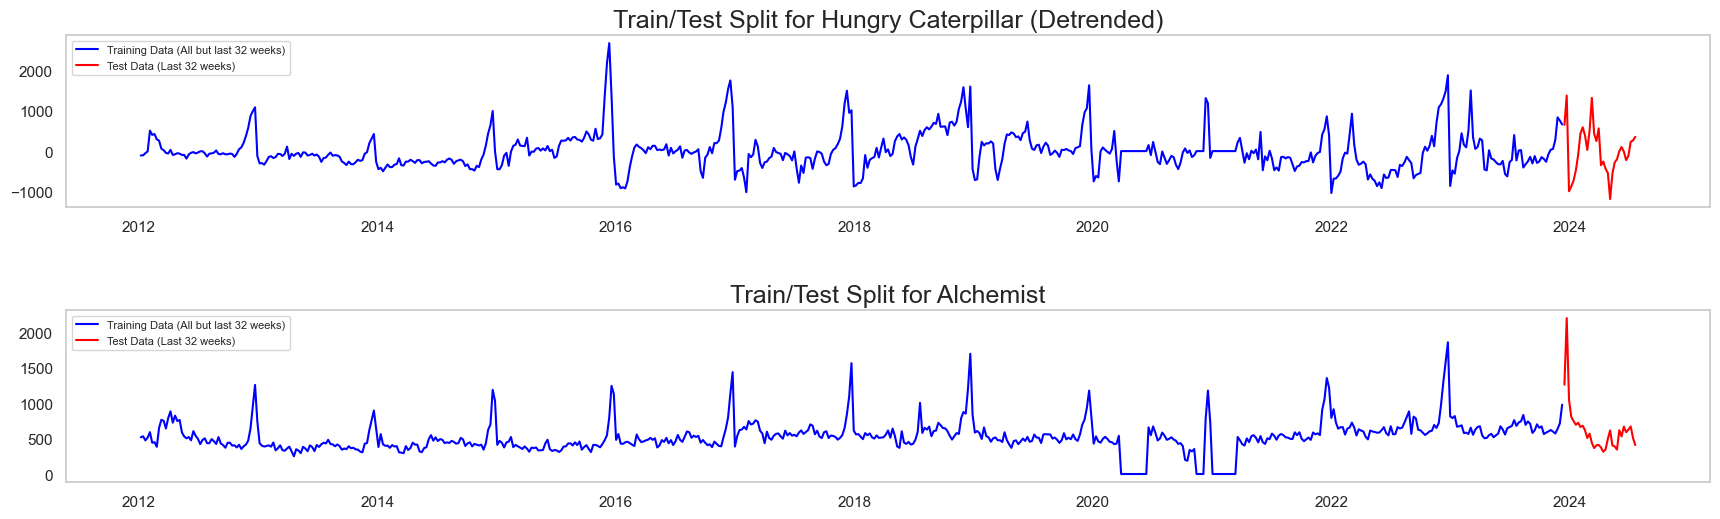

In [40]:
# Plot the sets of training and test dataset for both books

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 6))
ax1.plot(ts_train_hung_caterp_detrended.index, ts_train_hung_caterp_detrended, label="Training Data (All but last 32 weeks)", color="blue")
ax1.plot(ts_test_hung_caterp_detrended.index, ts_test_hung_caterp_detrended, label="Test Data (Last 32 weeks)", color="red")
ax1.set_title("Train/Test Split for Hungry Caterpillar (Detrended)", fontsize=18)
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(False)

ax2.plot(ts_train_alchemist.index, ts_train_alchemist, label="Training Data (All but last 32 weeks)", color="blue")
ax2.plot(ts_test_alchemist.index, ts_test_alchemist, label="Test Data (Last 32 weeks)", color="red")
ax2.set_title("Train/Test Split for Alchemist", fontsize=18)
ax2.legend(loc='upper left', fontsize=8)
ax2.grid(False)

plt.tight_layout(pad=3.0)
plt.show()

### Modeling The Very Hungry Caterpillar Detrended

In [25]:
# Define the five following SARIMA models in the form of a python list of order combinations [(p, d, q), (P, D, Q, m)]
# For The Hungry Caterpillar detrended data, we will use the following SARIMA parameters:
# m = 52 # Weekly seasonality
# D = 0 # No seasonal differencing
# P = 1 # Seasonal autoregressive order. PACF shows a significant spike at lag 52
# Q = 1 # Seasonal moving average order. ACF shows a significant spike at lag 52
# p = 1 # Non-seasonal autoregressive order. PACF shows a significant spike at lag 1
# d = 0 # Non-seasonal differencing. ADF and KPSS tests show that the series is stationary after detrending
# q = 1 # Non-seasonal moving average order. ACF shows significant spikes within the first 3 lags


sarima_orders = [
    # ==== Simplified Core Models (Baseline) ====
    ((1, 0, 1), (0, 0, 1, 52)),    # Seasonal MA only (simpler than P=1,Q=1)
    ((1, 0, 1), (1, 0, 0, 52)),     # Seasonal AR only
    ((0, 0, 1), (0, 0, 1, 52)),     # Minimal: Non-seasonal MA + Seasonal MA

    # ==== Differencing Models (Stationarity) ====
    ((1, 1, 1), (0, 0, 1, 52)),     # Non-seasonal differencing (d=1)
    ((1, 0, 1), (0, 1, 1, 52)),     # Seasonal differencing (D=1)
    ((0, 1, 1), (0, 0, 1, 52)),     # Non-seasonal diff + Seasonal MA

    # ==== Non-Seasonal Dominant Models ====
    ((1, 0, 1), (0, 0, 0, 52)),     # No seasonality (ARIMA baseline)
    ((2, 0, 1), (0, 0, 0, 52)),     # AR(2) + MA(1) (no seasonality)

    # ==== Original Benchmark ====
    ((1, 0, 1), (1, 0, 1, 52)),     # Original for comparison

    # ==== Reduced Seasonal Complexity ====
    ((1, 0, 0), (0, 0, 1, 52)),     # AR(1) + Seasonal MA(1)
    ((0, 0, 1), (1, 0, 0, 52)),     # MA(1) + Seasonal AR(1)
    ((1, 0, 1), (0, 0, 2, 52)),     # Seasonal MA(2) (no AR)

    # ==== Alternative Seasonal Configurations ====
    ((1, 0, 0), (1, 0, 0, 52)),     # AR(1) + Seasonal AR(1)
    ((0, 0, 1), (0, 0, 2, 52)),     # MA(1) + Seasonal MA(2)
]

# Fit the SARIMA models and store results
sarima_models_hungry_caterpillar = []
for order in sarima_orders:
    model = SARIMAX(
        ts_train_hung_caterp_detrended,
        order=order[0],
        seasonal_order=order[1],
        enforce_stationarity=True,  # Constrain parameters
        enforce_invertibility=True
    ).fit(
        method='powell',  # More robust but slower optimizer
        maxiter=200,      # Increase iterations
        disp=False
    )
    sarima_models_hungry_caterpillar.append(model)

# Print summary of each model
for i, model in enumerate(sarima_models_hungry_caterpillar):
    print(f"\nModel {i+1} Summary:")
    print(model.summary())
    print("\n" + "="*80 + "\n")

/opt/miniconda3/envs/ts/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'



Model 1 Summary:
                                     SARIMAX Results                                      
Dep. Variable:                             Volume   No. Observations:                  623
Model:             SARIMAX(1, 0, 1)x(0, 0, 1, 52)   Log Likelihood               -4392.336
Date:                            Sat, 16 Aug 2025   AIC                           8792.673
Time:                                    12:28:09   BIC                           8810.411
Sample:                                01-07-2012   HQIC                          8799.566
                                     - 12-09-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6760      0.025     26.561      0.000       0.626       0.726
ma.L1          0.

In [26]:
# Identify best models using MSE and AIC for The Hungry Caterpillar detrended data
mse_values = []
aic_values = []

# Calculate MSE and AIC for all models
for i, model in enumerate(sarima_models_hungry_caterpillar):
    # Get predictions for the test period
    predictions = model.predict(start=ts_test_hung_caterp_detrended.index[0], 
                               end=ts_test_hung_caterp_detrended.index[-1])
    
    # Calculate MSE
    mse = mean_squared_error(ts_test_hung_caterp_detrended, predictions)
    
    # Get AIC
    aic = model.aic
    
    # Store values
    mse_values.append((i+1, mse))  # (model_number, mse)
    aic_values.append((i+1, aic))  # (model_number, aic)
    
    print(f'Model {i+1}: MSE = {mse:.2f}, AIC = {aic:.2f}')

# Sort models by MSE (ascending order - lower is better)
mse_values_sorted = sorted(mse_values, key=lambda x: x[1])

# Sort models by AIC (ascending order - lower is better)
aic_values_sorted = sorted(aic_values, key=lambda x: x[1])

# Get top 3 models by MSE
top_3_mse = mse_values_sorted[:3]

# Get top 3 models by AIC
top_3_aic = aic_values_sorted[:3]

# Print results
print('\nTop 3 Models by MSE:')
for rank, (model_num, mse) in enumerate(top_3_mse, start=1):
    print(f'Rank {rank}: Model {model_num} with MSE: {mse:.2f}')

print('\nTop 3 Models by AIC:')
for rank, (model_num, aic) in enumerate(top_3_aic, start=1):
    print(f'Rank {rank}: Model {model_num} with AIC: {aic:.2f}')

# Best model by MSE
best_mse_model = top_3_mse[0][0]
best_mse_value = top_3_mse[0][1]
print(f'\nBest model by MSE is Model {best_mse_model} with MSE: {best_mse_value:.2f}')

# Best model by AIC
best_aic_model = top_3_aic[0][0]
best_aic_value = top_3_aic[0][1]
print(f'Best model by AIC is Model {best_aic_model} with AIC: {best_aic_value:.2f}')

Model 1: MSE = 246911.19, AIC = 8792.67
Model 2: MSE = 186091.85, AIC = 8739.87
Model 3: MSE = 244006.01, AIC = 8943.85
Model 4: MSE = 313708.86, AIC = 8864.83
Model 5: MSE = 192414.75, AIC = 8041.90
Model 6: MSE = 314666.67, AIC = 8861.25
Model 7: MSE = 335421.28, AIC = 8897.68
Model 8: MSE = 326844.03, AIC = 8896.17
Model 9: MSE = 185548.23, AIC = 8723.57
Model 10: MSE = 248272.49, AIC = 8792.04
Model 11: MSE = 187187.87, AIC = 8895.29
Model 12: MSE = 194688.62, AIC = 8761.51
Model 13: MSE = 186437.34, AIC = 8737.87
Model 14: MSE = 197481.04, AIC = 8922.80

Top 3 Models by MSE:
Rank 1: Model 9 with MSE: 185548.23
Rank 2: Model 2 with MSE: 186091.85
Rank 3: Model 13 with MSE: 186437.34

Top 3 Models by AIC:
Rank 1: Model 5 with AIC: 8041.90
Rank 2: Model 9 with AIC: 8723.57
Rank 3: Model 13 with AIC: 8737.87

Best model by MSE is Model 9 with MSE: 185548.23
Best model by AIC is Model 5 with AIC: 8041.90


### Modeling the Alchemist

In [27]:
# For The Alchemist data, we will use the following SARIMA parameters:
# m = 52 # Weekly seasonality
# D = 0 # No seasonal differencing
# P = 1 # Seasonal autoregressive order. PACF shows a significant spike at lag 52
# Q = 1 # Seasonal moving average order. ACF shows a significant spike at lag 52
# p = 1 # Non-seasonal autoregressive order. PACF shows a significant spike at lag 1
# d = 0 # Non-seasonal differencing. ADF and KPSS tests show that the series is stationary and no further differencing is needed
# q = 1 # Non-seasonal moving average order. ACF shows significant spikes within the first 4 lags

sarima_orders = [
    # ==== Baseline Models (Simpler Alternatives) ====
    ((1, 0, 1), (0, 0, 1, 52)),    # Seasonal MA only (simpler than P=1,Q=1)
    ((1, 0, 1), (1, 0, 0, 52)),    # Seasonal AR only
    ((0, 0, 1), (0, 0, 1, 52)),    # Non-seasonal MA + Seasonal MA (minimal)
    
    # ==== Differencing Models (Address Potential Non-Stationarity) ====
    ((1, 1, 1), (0, 0, 1, 52)),    # Non-seasonal differencing (d=1)
    ((1, 0, 1), (0, 1, 1, 52)),    # Seasonal differencing (D=1)
    ((0, 1, 1), (0, 0, 1, 52)),    # Non-seasonal differencing + Seasonal MA
    
    # ==== Non-Seasonal Focus (If Seasonality is Weak) ====
    ((1, 0, 1), (0, 0, 0, 52)),    # No seasonality (pure ARIMA)
    ((2, 0, 1), (0, 0, 0, 52)),    # AR(2) + MA(1) (no seasonality)
    
    # ==== Original Model (For Comparison) ====
    ((1, 0, 1), (1, 0, 1, 52)),   # Keep original for benchmarking
    
    # ==== Reduced Seasonal Complexity ====
    ((1, 0, 1), (1, 0, 0, 52)),   # Seasonal AR(1) only
    ((1, 0, 1), (0, 0, 2, 52)),    # Seasonal MA(2) (instead of P=1,Q=1)
    
    # ==== Alternative Optimizer-Friendly Models ====
    ((1, 0, 0), (0, 0, 1, 52)),    # AR(1) + Seasonal MA(1)
    ((0, 0, 1), (1, 0, 0, 52)),    # MA(1) + Seasonal AR(1)
]

# Fit the SARIMA models and store results
sarima_models_alchemist = []
for order in sarima_orders:
    model = SARIMAX(ts_train_alchemist, order=order[0], seasonal_order=order[1]).fit(disp=False)
    sarima_models_alchemist.append(model)
# Print summary of each model
for i, model in enumerate(sarima_models_alchemist):
    print(f"\nModel {i+1} Summary:")
    print(model.summary())
    print("\n" + "="*80 + "\n")

/opt/miniconda3/envs/ts/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



Model 1 Summary:
                                     SARIMAX Results                                      
Dep. Variable:                             Volume   No. Observations:                  623
Model:             SARIMAX(1, 0, 1)x(0, 0, 1, 52)   Log Likelihood               -3917.189
Date:                            Sat, 16 Aug 2025   AIC                           7842.378
Time:                                    12:29:46   BIC                           7860.117
Sample:                                01-07-2012   HQIC                          7849.272
                                     - 12-09-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9612      0.010     91.938      0.000       0.941       0.982
ma.L1         -0.

In [28]:
# Identify best models using MSE and AIC for The Alchemist data
mse_values = []
aic_values = []

# Calculate MSE and AIC for all models
for i, model in enumerate(sarima_models_alchemist):
    # Get predictions for the test period
    predictions = model.predict(start=ts_test_alchemist.index[0], 
                               end=ts_test_alchemist.index[-1])
    
    # Calculate MSE
    mse = mean_squared_error(ts_test_alchemist, predictions)
    
    # Get AIC
    aic = model.aic
    
    # Store values
    mse_values.append((i+1, mse))  # (model_number, mse)
    aic_values.append((i+1, aic))  # (model_number, aic)
    
    print(f'Model {i+1}: MSE = {mse:.2f}, AIC = {aic:.2f}')

# Sort models by MSE (ascending order - lower is better)
mse_values_sorted = sorted(mse_values, key=lambda x: x[1])

# Sort models by AIC (ascending order - lower is better)
aic_values_sorted = sorted(aic_values, key=lambda x: x[1])

# Get top 3 models by MSE
top_3_mse = mse_values_sorted[:3]

# Get top 3 models by AIC
top_3_aic = aic_values_sorted[:3]

# Print results
print('\nTop 3 Models by MSE:')
for rank, (model_num, mse) in enumerate(top_3_mse, start=1):
    print(f'Rank {rank}: Model {model_num} with MSE: {mse:.2f}')

print('\nTop 3 Models by AIC:')
for rank, (model_num, aic) in enumerate(top_3_aic, start=1):
    print(f'Rank {rank}: Model {model_num} with AIC: {aic:.2f}')

# Best model by MSE
best_mse_model = top_3_mse[0][0]
best_mse_value = top_3_mse[0][1]
print(f'\nBest model by MSE is Model {best_mse_model} with MSE: {best_mse_value:.2f}')

# Best model by AIC
best_aic_model = top_3_aic[0][0]
best_aic_value = top_3_aic[0][1]
print(f'Best model by AIC is Model {best_aic_model} with AIC: {best_aic_value:.2f}')

Model 1: MSE = 59689.33, AIC = 7842.38
Model 2: MSE = 45915.61, AIC = 7706.06
Model 3: MSE = 222478.78, AIC = 8658.25
Model 4: MSE = 60178.66, AIC = 7774.96
Model 5: MSE = 47692.82, AIC = 7014.37
Model 6: MSE = 93167.20, AIC = 7836.87
Model 7: MSE = 79335.45, AIC = 7997.35
Model 8: MSE = 78926.44, AIC = 7998.31
Model 9: MSE = 49297.47, AIC = 7653.42
Model 10: MSE = 45915.61, AIC = 7706.06
Model 11: MSE = 50320.54, AIC = 7751.83
Model 12: MSE = 63789.76, AIC = 7843.09
Model 13: MSE = 24020.67, AIC = 8165.28

Top 3 Models by MSE:
Rank 1: Model 13 with MSE: 24020.67
Rank 2: Model 2 with MSE: 45915.61
Rank 3: Model 10 with MSE: 45915.61

Top 3 Models by AIC:
Rank 1: Model 5 with AIC: 7014.37
Rank 2: Model 9 with AIC: 7653.42
Rank 3: Model 2 with AIC: 7706.06

Best model by MSE is Model 13 with MSE: 24020.67
Best model by AIC is Model 5 with AIC: 7014.37


### Plotting the Forecasts by best models for both books

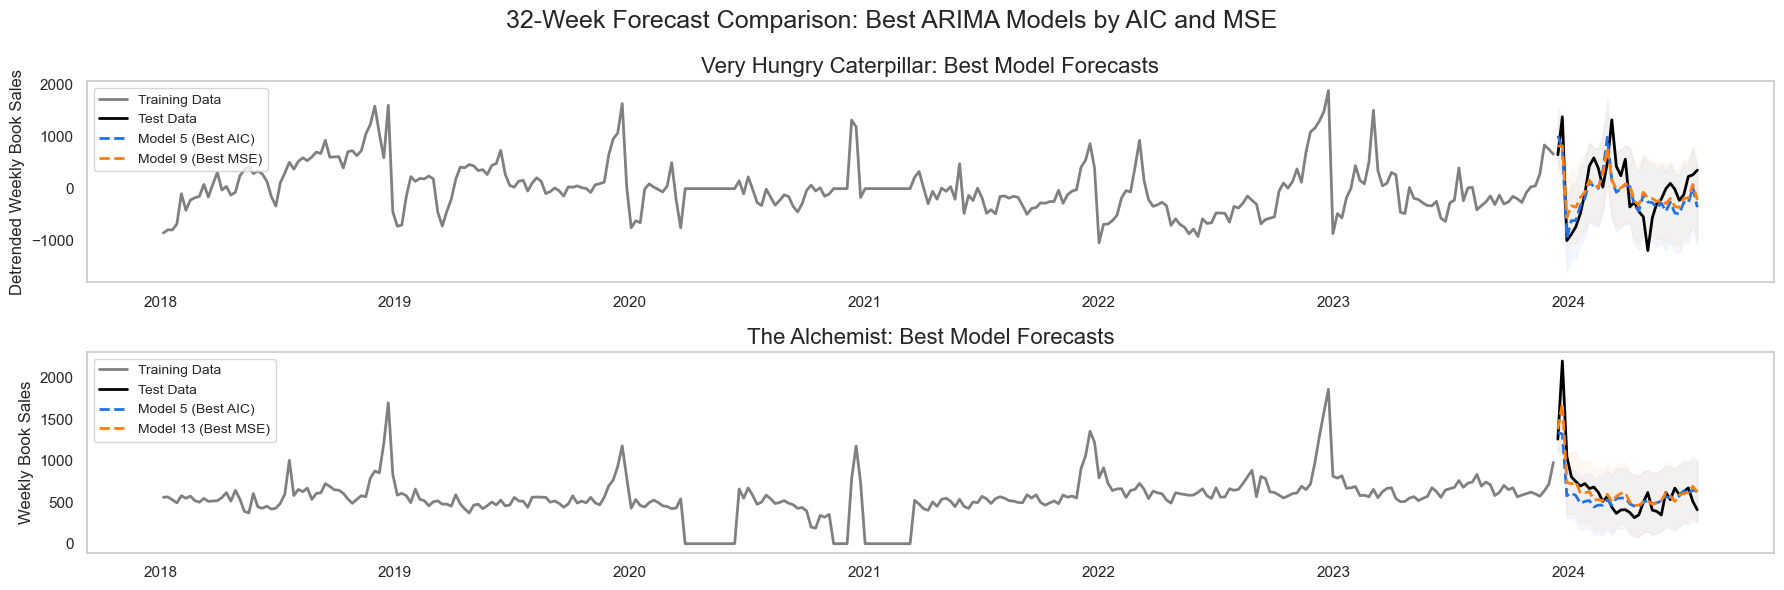

In [42]:
# @title: Forecasting Best Models Arima
# Forecast next 32 weeks

# Best models for Hungry Caterpillar
# Best model by MSE is Model 9 with MSE: 185548.23
# Best model by AIC is Model 5 with AIC: 8041.90
best_model_indices_hungry = [4, 8]
model_labels_hungry = ['Model 5 (Best AIC)', 'Model 9 (Best MSE)']
colors_hungry = ["#2173e5", '#ff7f0e']  # Blue for AIC, Orange for MSE

# Best models for Alchemist
# Best model by MSE is Model 13 with MSE: 24020.67
# Best model by AIC is Model 5 with AIC: 7014.37
best_model_indices_alchemist = [4, 12]
model_labels_alchemist = ['Model 5 (Best AIC)', 'Model 13 (Best MSE)']
colors_alchemist = ["#2173e5", '#ff7f0e']  # Green for AIC, Red for MSE

# Generate forecasts
forecasts_hungry = [
    sarima_models_hungry_caterpillar[4].get_forecast(steps=32),  # Model 5 (Best AIC)
    sarima_models_hungry_caterpillar[8].get_forecast(steps=32)   # Model 9 (Best MSE)
]

forecasts_alchemist = [
    sarima_models_alchemist[4].get_forecast(steps=32),  # Model 5 (Best AIC)
    sarima_models_alchemist[12].get_forecast(steps=32)   # Model 13 (Best MSE)
]

# Plotting
plt.figure(figsize=(18, 6))
training_start_date = '2018-01-01' # for better clarity. Full period starts from 2012-01-07

# 1. Hungry Caterpillar Plot
plt.subplot(2, 1, 1)
plt.plot(ts_train_hung_caterp_detrended[ts_train_hung_caterp_detrended.index >= training_start_date],
         label='Training Data', color='gray', linewidth=2)
plt.plot(ts_test_hung_caterp_detrended,
         label='Test Data', color='black', linewidth=2)

# Plot Model 5 (Best AIC)
plt.plot(forecasts_hungry[0].predicted_mean,
         label=model_labels_hungry[0],
         linestyle='--',
         linewidth=2,
         color=colors_hungry[0])
plt.fill_between(forecasts_hungry[0].conf_int().index,
                forecasts_hungry[0].conf_int().iloc[:, 0],
                forecasts_hungry[0].conf_int().iloc[:, 1],
                color=colors_hungry[0], alpha=0.05)

# Plot Model 9 (Best MSE)
plt.plot(forecasts_hungry[1].predicted_mean,
         label=model_labels_hungry[1],
         linestyle='--',
         linewidth=2,
         color=colors_hungry[1])
plt.fill_between(forecasts_hungry[1].conf_int().index,
                forecasts_hungry[1].conf_int().iloc[:, 0],
                forecasts_hungry[1].conf_int().iloc[:, 1],
                color=colors_hungry[1], alpha=0.05)

plt.title('Very Hungry Caterpillar: Best Model Forecasts', fontsize=16)
plt.ylabel('Detrended Weekly Book Sales', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(alpha=False)

# 2. Alchemist Plot
plt.subplot(2, 1, 2)
plt.plot(ts_train_alchemist[ts_train_alchemist.index >= training_start_date],
         label='Training Data', color='gray', linewidth=2)
plt.plot(ts_test_alchemist,
         label='Test Data', color='black', linewidth=2)

# Plot Model 4 (Best AIC)
plt.plot(forecasts_alchemist[0].predicted_mean,
         label=model_labels_alchemist[0],
         linestyle='--',
         linewidth=2,
         color=colors_alchemist[0])
plt.fill_between(forecasts_alchemist[0].conf_int().index,
                forecasts_alchemist[0].conf_int().iloc[:, 0],
                forecasts_alchemist[0].conf_int().iloc[:, 1],
                color=colors_alchemist[0], alpha=0.05)

# Plot Model 10 (Best MSE)
plt.plot(forecasts_alchemist[1].predicted_mean,
         label=model_labels_alchemist[1],
         linestyle='--',
         linewidth=2,
         color=colors_alchemist[1])
plt.fill_between(forecasts_alchemist[1].conf_int().index,
                forecasts_alchemist[1].conf_int().iloc[:, 0],
                forecasts_alchemist[1].conf_int().iloc[:, 1],
                color=colors_alchemist[1], alpha=0.05)

plt.title('The Alchemist: Best Model Forecasts', fontsize=16)
plt.ylabel('Weekly Book Sales', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(alpha=False)

plt.suptitle('32-Week Forecast Comparison: Best ARIMA Models by AIC and MSE', fontsize=18)
plt.tight_layout()
plt.show()

### Modeling the Very Hungry Caterpillar Detrended with Auto ARIMA

In [30]:
# Fit the training set for the hungry caterpillar detrended using the Auto ARIMA function with parameters set based on the analysis above.

# Optimised auto_arima based on manual model analysis
auto_arima_model_hung_caterpillar = auto_arima(
    ts_train_hung_caterp_detrended,
    seasonal=True,
    m=52,
    
    # Non-seasonal orders (p, d, q)
    start_p=0, max_p=2,
    d=0,  # Correctly fixed, as stationarity tests and model results support it.
    start_q=0, max_q=2,
    
    # Seasonal orders (P, D, Q)
    start_P=0, max_P=1,
    D=None,  # CRITICAL CHANGE: Let auto_arima test for D=1.
    start_Q=0, max_Q=1,
    
    # Optimization settings
    stepwise=True,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    n_jobs=-1
)

# Print the best model found
print(auto_arima_model_hung_caterpillar.summary())

/opt/miniconda3/envs/ts/lib/python3.10/site-packages/pmdarima/arima/_validation.py:76: UserWarning: stepwise model cannot be fit in parallel (n_jobs=1). Falling back to stepwise parameter search.
  warnings.warn('stepwise model cannot be fit in parallel (n_jobs=%i). '


Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[52] intercept   : AIC=9407.487, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[52] intercept   : AIC=8739.858, Time=2.57 sec
 ARIMA(0,0,1)(0,0,1)[52] intercept   : AIC=8945.848, Time=2.55 sec
 ARIMA(0,0,0)(0,0,0)[52]             : AIC=9405.488, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[52] intercept   : AIC=8905.466, Time=0.02 sec
 ARIMA(1,0,0)(1,0,1)[52] intercept   : AIC=8724.146, Time=5.21 sec
 ARIMA(1,0,0)(0,0,1)[52] intercept   : AIC=8794.028, Time=2.24 sec
 ARIMA(0,0,0)(1,0,1)[52] intercept   : AIC=9175.818, Time=3.98 sec
 ARIMA(2,0,0)(1,0,1)[52] intercept   : AIC=8725.680, Time=4.85 sec
 ARIMA(1,0,1)(1,0,1)[52] intercept   : AIC=8725.585, Time=6.53 sec
 ARIMA(0,0,1)(1,0,1)[52] intercept   : AIC=8882.306, Time=4.63 sec
 ARIMA(2,0,1)(1,0,1)[52] intercept   : AIC=inf, Time=11.72 sec
 ARIMA(1,0,0)(1,0,1)[52]             : AIC=8722.148, Time=3.95 sec
 ARIMA(1,0,0)(0,0,1)[52]             : AIC=8792.037, Time=2.24 sec
 ARIMA(1,0,0)(1,0,0)[52

In [31]:
#Convert the Auto ARIMA model to a SARIMAX model for further use
# Best model:  ARIMA(1,0,0)(1,0,1)[52]
sarimax_model_best_auto_sarima_hungry_caterpillar = SARIMAX(ts_train_hung_caterp_detrended, 
                order=(1,0,0),
                seasonal_order=(1,0,1,52)).fit()

# Now you can use get_forecast()
forecast_best_auto_arima_hungry_caterpillar = sarimax_model_best_auto_sarima_hungry_caterpillar.get_forecast(steps=32)

In [32]:
# For pmdarima models, use predict() method
n_periods = len(ts_test_hung_caterp_detrended)  # Number of periods to forecast
auto_arima_pred_hung_caterpillar, auto_arima_conf_int_hung_caterpillar = auto_arima_model_hung_caterpillar.predict(
    n_periods=n_periods, 
    return_conf_int=True
)

### Modeling the Alchemist with Auto ARIMA

In [33]:
# Fit the training set for the Alchemist using the Auto ARIMA function with parameters set based on the analysis above.

auto_arima_model_alchemist = auto_arima(
    ts_train_alchemist,
    seasonal=True,
    m=52,  # Weekly seasonality
    
    # Non-seasonal orders (p, d, q)
    start_p=0, max_p=2,  # AR(p) → 0 to 2
    d=0,                 # No differencing (since best models used d=0)
    start_q=0, max_q=2,  # MA(q) → 0 to 2
    
    # Seasonal orders (P, D, Q)
    start_P=0, max_P=1,  # Seasonal AR → 0 to 1
    D=None,              # Allow auto_arima to test for seasonal differencing.
    start_Q=0, max_Q=1,  # Seasonal MA → 0 to 1
    
    # Optimization settings
    stepwise=True,       # Faster search
    trace=True,          # Print progress
    error_action="ignore",  # Skip invalid models
    suppress_warnings=True,
    max_order=10,        # Prevent overly complex models
    n_jobs=-1            # Parallel processing
)

# Print the best model found
print(auto_arima_model_alchemist.summary())

/opt/miniconda3/envs/ts/lib/python3.10/site-packages/pmdarima/arima/_validation.py:76: UserWarning: stepwise model cannot be fit in parallel (n_jobs=1). Falling back to stepwise parameter search.
  warnings.warn('stepwise model cannot be fit in parallel (n_jobs=%i). '


Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[52] intercept   : AIC=8485.150, Time=0.03 sec
 ARIMA(1,0,0)(1,0,0)[52] intercept   : AIC=inf, Time=6.72 sec
 ARIMA(0,0,1)(0,0,1)[52] intercept   : AIC=7988.526, Time=4.57 sec
 ARIMA(0,0,0)(0,0,0)[52]             : AIC=9669.899, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[52] intercept   : AIC=8110.153, Time=0.11 sec
 ARIMA(0,0,1)(1,0,1)[52] intercept   : AIC=7985.844, Time=8.09 sec
 ARIMA(0,0,1)(1,0,0)[52] intercept   : AIC=7942.434, Time=6.08 sec
 ARIMA(0,0,0)(1,0,0)[52] intercept   : AIC=8316.986, Time=3.94 sec
 ARIMA(1,0,1)(1,0,0)[52] intercept   : AIC=7678.056, Time=7.97 sec
 ARIMA(1,0,1)(0,0,0)[52] intercept   : AIC=7928.247, Time=0.03 sec
 ARIMA(1,0,1)(1,0,1)[52] intercept   : AIC=7662.966, Time=9.90 sec
 ARIMA(1,0,1)(0,0,1)[52] intercept   : AIC=7784.215, Time=3.18 sec
 ARIMA(1,0,0)(1,0,1)[52] intercept   : AIC=7754.724, Time=12.16 sec
 ARIMA(2,0,1)(1,0,1)[52] intercept   : AIC=inf, Time=14.91 sec
 ARIMA(1,0,2)(1,0,1)[52] in

In [34]:
#Convert the Auto ARIMA model to a SARIMAX model for further use
# Best model:  ARIMA(2,0,0)(1,0,1)[52]
sarimax_model_best_auto_sarima_alchemist = SARIMAX(ts_train_alchemist, 
                order=(2,0,0),
                seasonal_order=(1,0,1,52)).fit()

# Now you can use get_forecast()
forecast_best_auto_arima_alchemist = sarimax_model_best_auto_sarima_alchemist.get_forecast(steps=32)

In [35]:
# For pmdarima models, use predict() method
n_periods = len(ts_test_alchemist)  # Number of periods to forecast
auto_arima_pred_alchemist, auto_arima_conf_int_alchemist = auto_arima_model_alchemist.predict(
    n_periods=n_periods, 
    return_conf_int=True
)

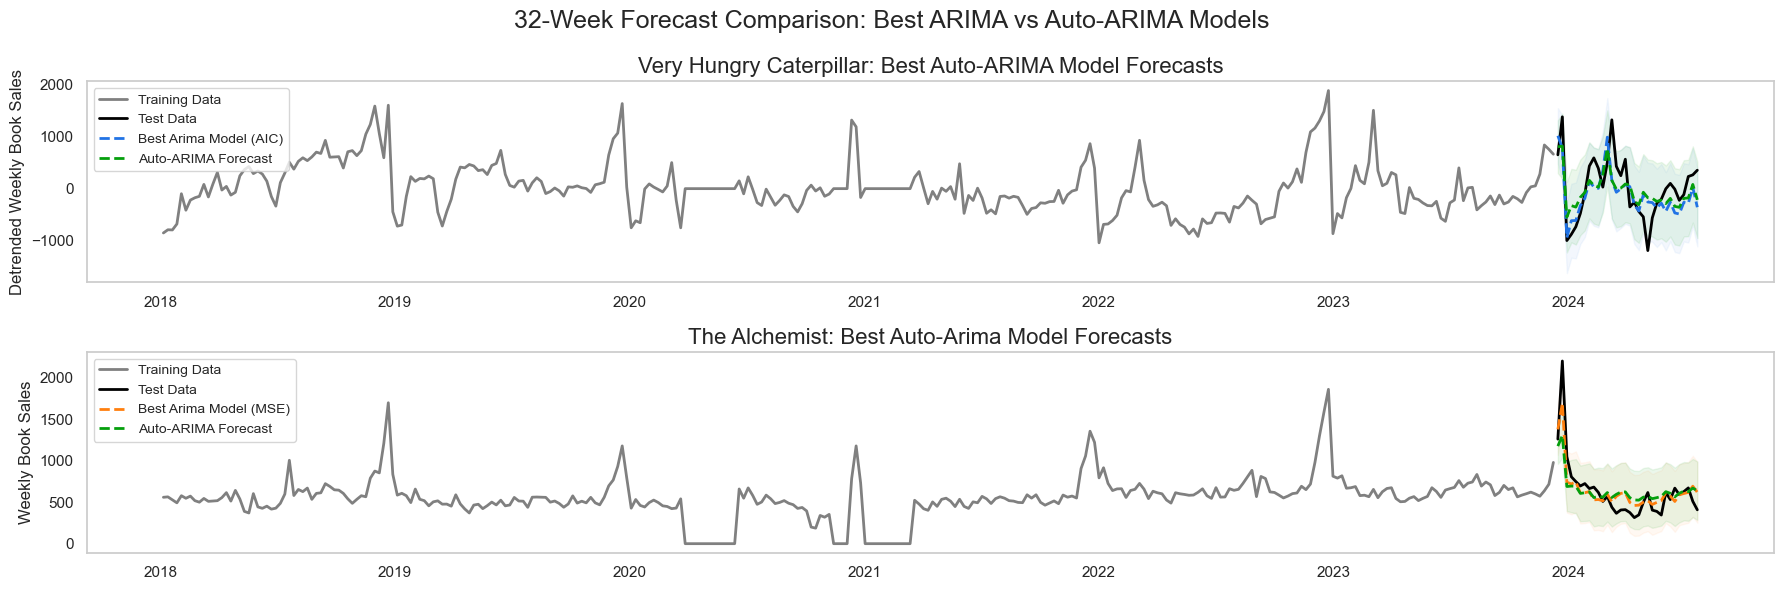

In [44]:
# @title: Forecasting Best Models Arima
# Forecast next 32 weeks

# Best models for Hungry Caterpillar
# Best model by MSE is Model 9 with MSE: 185548.23
# Best model by AIC is Model 5 with AIC: 8041.90
best_model_indices_hungry = [4, 8]
model_labels_hungry = ['Model 5 (Best AIC)', 'Model 9 (Best MSE)']
colors_hungry = ["#2173e5", '#ff7f0e']  # Blue for AIC, Orange for MSE

# Best models for Alchemist
# Best model by MSE is Model 13 with MSE: 24020.67
# Best model by AIC is Model 5 with AIC: 7014.37
best_model_indices_alchemist = [4, 12]
model_labels_alchemist = ['Model 5 (Best AIC)', 'Model 13 (Best MSE)']
colors_alchemist = ['#2173e5', '#ff7f0e']  # Green for AIC, Red for MSE

# Generate forecasts
forecasts_hungry = [
    sarima_models_hungry_caterpillar[4].get_forecast(steps=32),  # Model 5 (Best AIC)
    sarima_models_hungry_caterpillar[8].get_forecast(steps=32)   # Model 9 (Best MSE)
]

forecasts_alchemist = [
    sarima_models_alchemist[4].get_forecast(steps=32),  # Model 5 (Best AIC)
    sarima_models_alchemist[12].get_forecast(steps=32)   # Model 13 (Best MSE)
]

# ========================================= Plotting =========================================

plt.figure(figsize=(18, 6))
training_start_date = '2018-01-01' # for better clarity. Full period starts from 2012-01-07
#============================================ Plot The Very Hungry Caterpillar ============================================
# 1. Hungry Caterpillar Plot
plt.subplot(2, 1, 1)
plt.plot(ts_train_hung_caterp_detrended[ts_train_hung_caterp_detrended.index >= training_start_date],
         label='Training Data', color='gray', linewidth=2)
plt.plot(ts_test_hung_caterp_detrended,
         label='Test Data', color='black', linewidth=2)

# Plot Model 5 (Best AIC)
plt.plot(forecasts_hungry[0].predicted_mean,
         label='Best Arima Model (AIC)',
         linestyle='--',
         linewidth=2,
         color=colors_hungry[0])
plt.fill_between(forecasts_hungry[0].conf_int().index,
                forecasts_hungry[0].conf_int().iloc[:, 0],
                forecasts_hungry[0].conf_int().iloc[:, 1],
                color=colors_hungry[0], alpha=0.05)

# # Plot Model 9 (Best MSE)
# plt.plot(forecasts_hungry[1].predicted_mean,
#          label=model_labels_hungry[1],
#          linestyle='--',
#          linewidth=2,
#          color=colors_hungry[1])
# plt.fill_between(forecasts_hungry[1].conf_int().index,
#                 forecasts_hungry[1].conf_int().iloc[:, 0],
#                 forecasts_hungry[1].conf_int().iloc[:, 1],
#                 color=colors_hungry[1], alpha=0.05)

# Plot Best Model Auto Arima Hungry Caterpillar
# Create proper index for the forecast
forecast_index = ts_test_hung_caterp_detrended.index

plt.plot(forecast_index, auto_arima_pred_hung_caterpillar,
         label='Auto-ARIMA Forecast',
         linestyle='--',
         linewidth=2,
         color="#049f0c")  # Green

# Plot confidence intervals for Auto-ARIMA
try:
    plt.fill_between(forecast_index,
                    auto_arima_conf_int_hung_caterpillar[:, 0],  # Lower bound
                    auto_arima_conf_int_hung_caterpillar[:, 1],  # Upper bound
                    color='#049f0c', alpha=0.08)
except Exception as e:
    print(f"Note: Could not plot confidence intervals for Auto-ARIMA: {e}")
    plt.plot(forecast_index, auto_arima_pred_hung_caterpillar,
             label='Auto-ARIMA Forecast',
             linestyle='--',
             linewidth=2,
             color="#049f0c")  # Green

plt.title('Very Hungry Caterpillar: Best Auto-ARIMA Model Forecasts', fontsize=16)
plt.ylabel('Detrended Weekly Book Sales', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(alpha=False)


#============================================ Plot The Alchemist ============================================

# 2. Alchemist Plot
plt.subplot(2, 1, 2)
plt.plot(ts_train_alchemist[ts_train_alchemist.index >= training_start_date],
         label='Training Data', color='gray', linewidth=2)
plt.plot(ts_test_alchemist,
         label='Test Data', color='black', linewidth=2)

# # Plot Model 5 (Best AIC)
# plt.plot(forecasts_alchemist[0].predicted_mean,
#          label=model_labels_alchemist[0],
#          linestyle='--',
#          linewidth=2,
#          color=colors_alchemist[0])
# plt.fill_between(forecasts_alchemist[0].conf_int().index,
#                 forecasts_alchemist[0].conf_int().iloc[:, 0],
#                 forecasts_alchemist[0].conf_int().iloc[:, 1],
#                 color=colors_alchemist[0], alpha=0.05)

# Plot Model 13 (Best MSE)
plt.plot(forecasts_alchemist[1].predicted_mean,
         label='Best Arima Model (MSE)',
         linestyle='--',
         linewidth=2,
         color=colors_alchemist[1])
plt.fill_between(forecasts_alchemist[1].conf_int().index,
                forecasts_alchemist[1].conf_int().iloc[:, 0],
                forecasts_alchemist[1].conf_int().iloc[:, 1],
                color=colors_alchemist[1], alpha=0.05)


# Plot Best Model Auto Arima Alchemist
# Create proper index for the forecast
forecast_index = ts_test_alchemist.index

plt.plot(forecast_index, auto_arima_pred_alchemist,
         label='Auto-ARIMA Forecast',
         linestyle='--',
         linewidth=2,
         color="#049f0c")  # Green

# Plot confidence intervals for Auto-ARIMA
try:
    plt.fill_between(forecast_index,
                    auto_arima_conf_int_alchemist[:, 0],  # Lower bound
                    auto_arima_conf_int_alchemist[:, 1],  # Upper bound
                    color='#049f0c', alpha=0.08)
except Exception as e:
    print(f"Note: Could not plot confidence intervals for Auto-ARIMA: {e}")
    plt.plot(forecast_index, auto_arima_pred_alchemist,
             label='Auto-ARIMA Forecast',
             linestyle='--',
             linewidth=2,
             color="#049f0c")  # Green

plt.title('The Alchemist: Best Auto-Arima Model Forecasts', fontsize=16)
plt.ylabel('Weekly Book Sales', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(alpha=False)

plt.suptitle('32-Week Forecast Comparison: Best ARIMA vs Auto-ARIMA Models', fontsize=18)
plt.tight_layout()
plt.show()

In [37]:
# @title: Auto-ARIMA Model Performance Comparison with Arima Models for both Books
sarima_models_hungry_caterpillar
# ===================================== Auto-ARIMA Model Performance Comparison =====================================
# ===================================== Hungry Caterpillar ======================
# These variables are already defined in the previous code
sarimax_model_best_auto_sarima_hungry_caterpillar 
# Forescast next 32 weeks
forecast_best_auto_arima_hungry_caterpillar

# AutoArima Predictions for Hungry Caterpillar
auto_arima_pred_hung_caterpillar
auto_arima_conf_int_hung_caterpillar 

# Calculate MSE for Auto-ARIMA model
auto_arima_mse_hc = mean_squared_error(ts_test_hung_caterp_detrended, auto_arima_pred_hung_caterpillar)

# Also calculate RMSE for additional context
auto_arima_rmse_hc = np.sqrt(auto_arima_mse_hc)

# Compare with Model 13 (Best MSE) from the previous analysis
sarima_models_hungry_caterpillar[4].get_forecast(steps=32),  # Model 5 (Best AIC)
# Get predictions for Model 5 (Best AIC)
forecasts_hc_arima = sarima_models_hungry_caterpillar[4].get_forecast(steps=32)
model5_pred = forecasts_hc_arima.predicted_mean  # Model 5 predictions
model5_mse = mean_squared_error(ts_test_hung_caterp_detrended, model5_pred)
model5_rmse = np.sqrt(model5_mse)

# Create a DataFrame to summarize the performance comparison
performance_comparison = pd.DataFrame({
    'Model': ['Auto-ARIMA', 'Model 5'],
    'MSE': [auto_arima_mse_hc, model5_mse],
    'RMSE': [auto_arima_rmse_hc, model5_rmse]
})

print("==================== Performance for The Hungry Caterpillar Set ====================\n")
print(f"Performance Summary:")
print(f"Model 5 - Best Model based on lowest AIC and plot performance VS auto Best Auto Arima Model:")
print(performance_comparison)

# ===================================== Alchemist ======================
# These variables are already defined in the previous code
sarimax_model_best_auto_sarima_alchemist
# Forescast next 32 weeks
forecast_best_auto_arima_alchemist

# AutoArima Predictions for Alchemist
auto_arima_pred_alchemist
auto_arima_conf_int_alchemist

# Calculate MSE for Auto-ARIMA model
auto_arima_mse_ac = mean_squared_error(ts_test_alchemist, auto_arima_pred_alchemist)

# Also calculate RMSE for additional context
auto_arima_rmse_ac = np.sqrt(auto_arima_mse_ac)

# Compare with Model 13 (Best MSE) from the previous analysis
sarima_models_alchemist[12].get_forecast(steps=32),  # Model 13 (Best MSE)
# Get predictions for Model 13 (Best MSE)
forecasts_ac_arima = sarima_models_alchemist[12].get_forecast(steps=32)
model13_pred = forecasts_ac_arima.predicted_mean  # Model 13 predictions
model13_mse = mean_squared_error(ts_test_alchemist, model13_pred)
model13_rmse = np.sqrt(model13_mse)


# Create a DataFrame to summarize the performance comparison
performance_comparison = pd.DataFrame({
    'Model': ['Auto-ARIMA', 'Model 13'],
    'MSE': [auto_arima_mse_ac, model13_mse],
    'RMSE': [auto_arima_rmse_ac, model13_rmse]
})
print("\n==================== Performance for The Alchemist Set ====================\n")
print(f"Performance Summary:")
print(f"Model 13 - Best Model based on lowest MSE and plot performance VS auto Best Auto Arima Model:")
print(f"\nPerformance Summary:")
print(performance_comparison)




==================== Performance for The Hungry Caterpillar Set ====================

Performance Summary:
Model 5 - Best Model based on lowest AIC and plot performance VS auto Best Auto Arima Model:
        Model            MSE        RMSE
0  Auto-ARIMA  185867.600911  431.123649
1     Model 5  192414.747912  438.651055

==================== Performance for The Alchemist Set ====================

Performance Summary:
Model 13 - Best Model based on lowest MSE and plot performance VS auto Best Auto Arima Model:

Performance Summary:
        Model           MSE        RMSE
0  Auto-ARIMA  46016.677588  214.514982
1    Model 13  24020.669222  154.986029


### Notes:

The Very Hungry Caterpillar:

- Best ARIMA model for The Very Hungry Caterpillar set is Model 5 with an AIC: 8041.90. This model also showed a good performance predicting the final 32 weeks of the dataset, which followed very closely the pattern of the 32 weeks of the test set.
- Best auto ARIMA model for The Very Hungry Caterpillar set is Model 4 with AIC: 8722.148. This model captures the patterns well and provides a good fit to the data, with a forecast performance that aligns closely with the actual sales data. This model performs slightly better than Arima Model 5, based on its lowest MSE and RMSE scores (MSE and RMASE for auto arima model: 185867.60 and 431.12 respectively, vs 192414.75 and 438.65 for Model 5).

The Alchemist:

- Best ARIMA model for The Alchemist set is Model 13 with an 24020.67. Although Model 5 showed the lowest AIC (7014.37), Model 13 displayed a better performance predicting the final 32 weeks of the dataset, which followed more closely the pattern of the 32 weeks of the test set.
- Best auto ARIMA model for The Alchemist with AIC: 7653.611. This model captures the seasonal patterns well, although Arima Model 13 follows more closely the actual data. This is aligned with the fact that Model 13 has a lower MSE (24020.67) and RMSE (154.99) compared to the auto ARIMA model (MSE: 40016.68, and RMSE: 214.51).


### Find Residuals for Best Model for The Very Hungry Caterpillar Detrended (Auto Arima Model)

Ljung-Box test result for weekly data:
      lb_stat  lb_pvalue
5    2.484554   0.778819
10  14.022706   0.171958
15  25.446032   0.044265

Jarque-Bera normality test:
Test statistic: 1016.3870, p-value: 0.0000

ARCH test for heteroscedasticity:
Test statistic: 71.4204, p-value: 0.0000


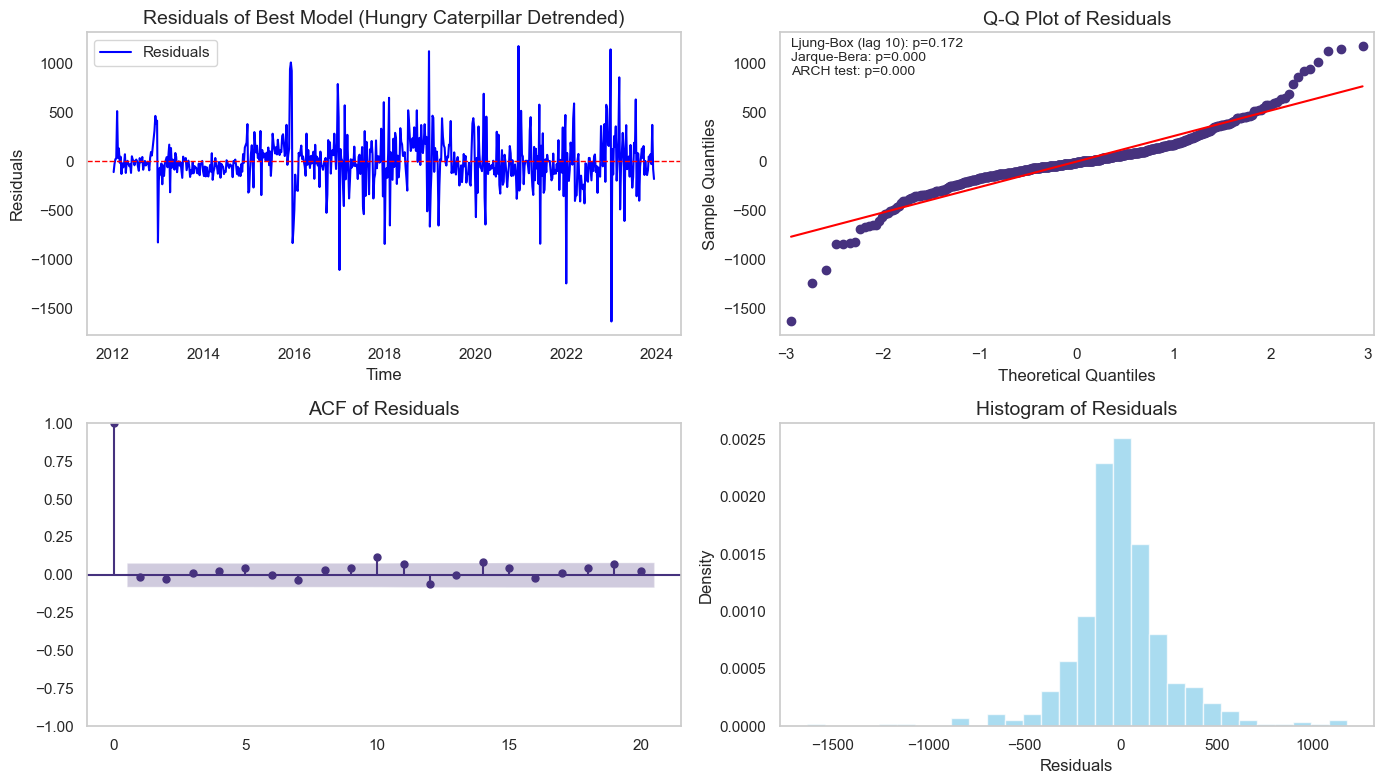


--- Residual Analysis Summary ---
Ljung-Box (lag 10): ✓ No autocorr. (p=0.172)
Normality: ✗ Non-normal (p=0.000)
Constant variance: ✗ Heteroscedastic (p=0.000)


In [38]:
# Find residuals for best model the hungry caterpillar detrended (Auto Arima Model)
residuals_best_model_hungry = sarimax_model_best_auto_sarima_hungry_caterpillar.resid

# Ljung-Box test for autocorrelation: H0: No autocorrelation. Reject null if p < 0.05
# Test multiple lags for more robust assessment
ljung_box_result = acorr_ljungbox(residuals_best_model_hungry, lags=[5, 10, 15], return_df=True)
print('Ljung-Box test result for weekly data:')
print(ljung_box_result)

# Jarque-Bera test for normality: H0: Residuals are normally distributed

jb_stat, jb_pvalue = jarque_bera(residuals_best_model_hungry.dropna())
print(f'\nJarque-Bera normality test:')
print(f'Test statistic: {jb_stat:.4f}, p-value: {jb_pvalue:.4f}')

# ARCH test for heteroscedasticity: H0: No ARCH effects (constant variance)

arch_result = het_arch(residuals_best_model_hungry.dropna(), nlags=5)
arch_stat, arch_pvalue = arch_result[0], arch_result[1]
print(f'\nARCH test for heteroscedasticity:')
print(f'Test statistic: {arch_stat:.4f}, p-value: {arch_pvalue:.4f}')

# Analyse residuals for the best model of the hungry caterpillar detrended
plt.figure(figsize=(14, 8))

# Residuals plot
plt.subplot(2, 2, 1)
plt.plot(residuals_best_model_hungry, label='Residuals', color='blue')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Residuals of Best Model (Hungry Caterpillar Detrended)', fontsize=14)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.legend()
plt.grid(False)

# Q-Q plot with test results
plt.subplot(2, 2, 2)
sm.qqplot(residuals_best_model_hungry, line='s', ax=plt.gca())
plt.title('Q-Q Plot of Residuals', fontsize=14)
plt.xlabel('Theoretical Quantiles', fontsize=12)
plt.ylabel('Sample Quantiles', fontsize=12)
# Add test results as text
plt.text(0.02, 0.98, f'Ljung-Box (lag 10): p={ljung_box_result.loc[10, "lb_pvalue"]:.3f}\n' +
                     f'Jarque-Bera: p={jb_pvalue:.3f}\n' +
                     f'ARCH test: p={arch_pvalue:.3f}', 
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.grid(False)

# ACF plot
plt.subplot(2, 2, 3)
sm.graphics.tsa.plot_acf(residuals_best_model_hungry.dropna(), lags=20, ax=plt.gca())
plt.title('ACF of Residuals', fontsize=14)
plt.grid(False)

# Histogram of residuals
plt.subplot(2, 2, 4)
plt.hist(residuals_best_model_hungry.dropna(), bins=30, density=True, alpha=0.7, color='skyblue')
plt.title('Histogram of Residuals', fontsize=14)
plt.xlabel('Residuals', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(False)

plt.tight_layout()
plt.show()

# Interpretation helper
print(f'\n--- Residual Analysis Summary ---')
print(f'Ljung-Box (lag 10): {"✓ No autocorr." if ljung_box_result.loc[10, "lb_pvalue"] > 0.05 else "✗ Autocorr. present"} (p={ljung_box_result.loc[10, "lb_pvalue"]:.3f})')
print(f'Normality: {"✓ Normal" if jb_pvalue > 0.05 else "✗ Non-normal"} (p={jb_pvalue:.3f})')
print(f'Constant variance: {"✓ Homoscedastic" if arch_pvalue > 0.05 else "✗ Heteroscedastic"} (p={arch_pvalue:.3f})')

### Find Residuals for Best Model for The Alchemist (Auto Arima Model)

Ljung-Box test result for weekly data:
        lb_stat      lb_pvalue
5    810.076807  7.643141e-173
10  1276.686000  4.110440e-268
15  1464.375476  2.326409e-303

Jarque-Bera normality test:
Test statistic: 85.3870, p-value: 0.0000

ARCH test for heteroscedasticity:
Test statistic: 211.0083, p-value: 0.0000


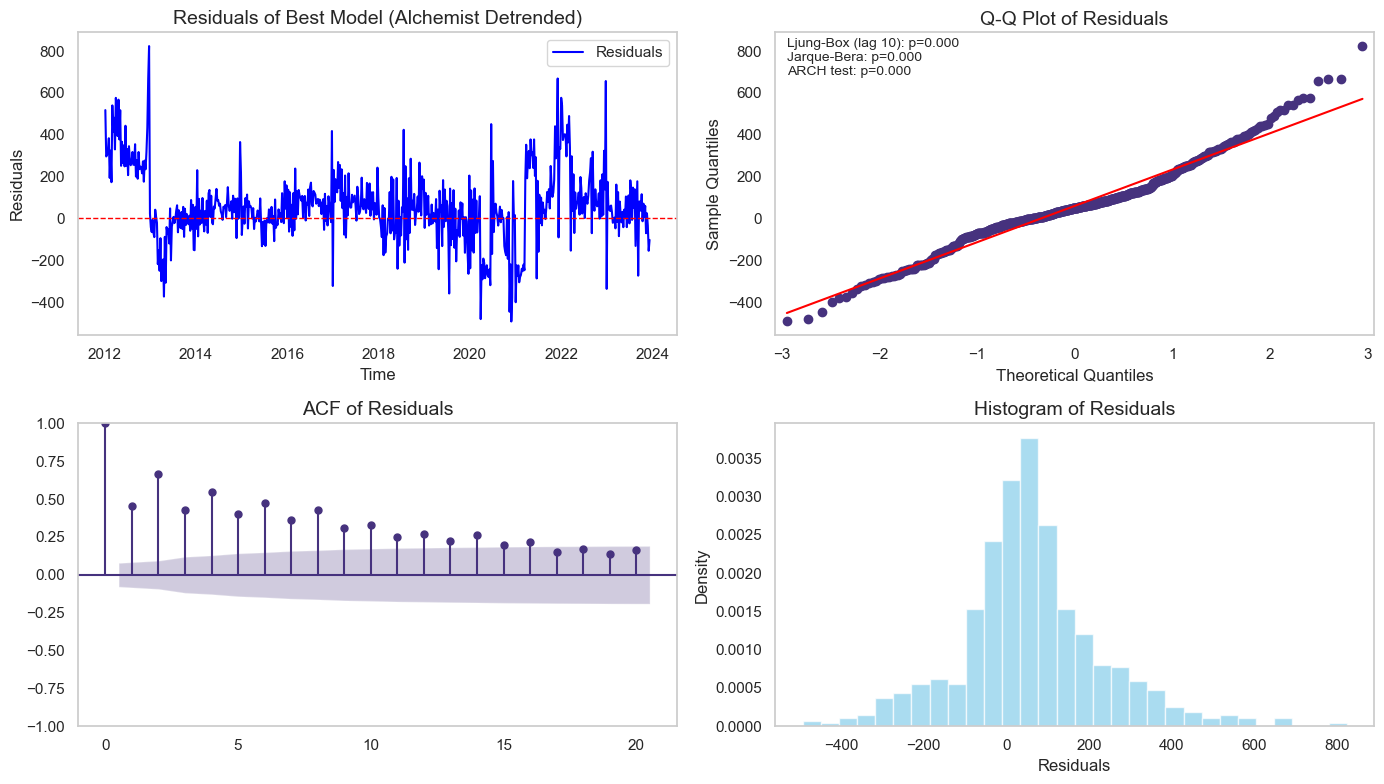


--- Residual Analysis Summary ---
Ljung-Box (lag 10): ✗ Autocorr. present (p=0.000)
Normality: ✗ Non-normal (p=0.000)
Constant variance: ✗ Heteroscedastic (p=0.000)


In [39]:
# Find residuals for best model the alchemist detrended (Arima Model 13)
residuals_best_model_alchemist = sarima_models_alchemist[12].resid

# Ljung-Box test for autocorrelation: H0: No autocorrelation. Reject null if p < 0.05
# Test multiple lags for more robust assessment
ljung_box_result = acorr_ljungbox(residuals_best_model_alchemist, lags=[5, 10, 15], return_df=True)
print('Ljung-Box test result for weekly data:')
print(ljung_box_result)

# Jarque-Bera test for normality: H0: Residuals are normally distributed

jb_stat, jb_pvalue = jarque_bera(residuals_best_model_alchemist.dropna())
print(f'\nJarque-Bera normality test:')
print(f'Test statistic: {jb_stat:.4f}, p-value: {jb_pvalue:.4f}')

# ARCH test for heteroscedasticity: H0: No ARCH effects (constant variance)

arch_result = het_arch(residuals_best_model_alchemist.dropna(), nlags=5)
arch_stat, arch_pvalue = arch_result[0], arch_result[1]
print(f'\nARCH test for heteroscedasticity:')
print(f'Test statistic: {arch_stat:.4f}, p-value: {arch_pvalue:.4f}')

# Analyse residuals for the best model of the hungry caterpillar detrended
plt.figure(figsize=(14, 8))

# Residuals plot
plt.subplot(2, 2, 1)
plt.plot(residuals_best_model_alchemist, label='Residuals', color='blue')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Residuals of Best Model (Alchemist Detrended)', fontsize=14)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.legend()
plt.grid(False)

# Q-Q plot with test results
plt.subplot(2, 2, 2)
sm.qqplot(residuals_best_model_alchemist, line='s', ax=plt.gca())
plt.title('Q-Q Plot of Residuals', fontsize=14)
plt.xlabel('Theoretical Quantiles', fontsize=12)
plt.ylabel('Sample Quantiles', fontsize=12)
# Add test results as text
plt.text(0.02, 0.98, f'Ljung-Box (lag 10): p={ljung_box_result.loc[10, "lb_pvalue"]:.3f}\n' +
                     f'Jarque-Bera: p={jb_pvalue:.3f}\n' +
                     f'ARCH test: p={arch_pvalue:.3f}', 
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.grid(False)

# ACF plot
plt.subplot(2, 2, 3)
sm.graphics.tsa.plot_acf(residuals_best_model_alchemist.dropna(), lags=20, ax=plt.gca())
plt.title('ACF of Residuals', fontsize=14)
plt.grid(False)
# Histogram of residuals
plt.subplot(2, 2, 4)
plt.hist(residuals_best_model_alchemist.dropna(), bins=30, density=True, alpha=0.7, color='skyblue')
plt.title('Histogram of Residuals', fontsize=14)
plt.xlabel('Residuals', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(False)

plt.tight_layout()
plt.show()

# Interpretation helper
print(f'\n--- Residual Analysis Summary ---')
print(f'Ljung-Box (lag 10): {"✓ No autocorr." if ljung_box_result.loc[10, "lb_pvalue"] > 0.05 else "✗ Autocorr. present"} (p={ljung_box_result.loc[10, "lb_pvalue"]:.3f})')
print(f'Normality: {"✓ Normal" if jb_pvalue > 0.05 else "✗ Non-normal"} (p={jb_pvalue:.3f})')
print(f'Constant variance: {"✓ Homoscedastic" if arch_pvalue > 0.05 else "✗ Heteroscedastic"} (p={arch_pvalue:.3f})')

### The Hungry Caterpillar Dataset

Summary:
The auto ARIMA model successfully captured core temporal patterns with no significant autocorrelation at lag 10. Non-normality and heteroscedasticity violations are present but common in retail data. Point forecasts remain reliable, though confidence intervals should be interpreted cautiously due to assumption violations.
Key Findings:

No autocorrelation detected (Ljung-Box p=0.172 at lag 10)
Non-normal residuals affecting confidence interval reliability
Time-varying variance present but not compromising point forecasts
Model performs primary forecasting function adequately

Recommendations:

Use model confidently for point forecasts
Apply bootstrap methods for robust uncertainty estimates
Consider log transformation to stabilize variance
Monitor forecast performance across different periods

### The Alchemist Dataset

Summary:
Residual diagnostics indicate severe model violations including autocorrelation and heteroscedasticity. However, visual forecast performance on test data appears strong, suggesting a disconnect between statistical diagnostics and practical forecasting utility. This highlights the distinction between statistical perfection and real-world model effectiveness.
Key Findings:

Severe residual autocorrelation detected in diagnostics
Strong heteroscedasticity and non-normality present
Visual forecast performance tracks test data well
Contradiction between diagnostic tests and practical performance

Recommendations:

Prioritize out-of-sample forecast accuracy over residual diagnostics
Verify model specification and consider manual parameter tuning
Explore alternative approaches if forecast performance deteriorates
Use diagnostic tests as guides rather than absolute criteria


### General Conclusions

Key Insight: Residual diagnostic failures don't always indicate poor forecasting performance. The primary goal is accurate predictions, not perfect statistical assumptions.
In the future, it is recommended to:

- Validate models using multiple criteria including visual inspection.
- Prioritize out-of-sample performance over in-sample diagnostics.
- Consider diagnostic violations as model limitations rather than failures.
- Focus on business-relevant accuracy metrics alongside statistical tests.